# 04 - Functional Enrichment: LUNG

ORA + GSEA on the lung Crystalline-vs-CTRL DEG list using:

- **Hallmark** (50 broad themes — quick big-picture overview)
- **GO Biological Process** (fine-grained biological processes)
- **KEGG** (curated pathways)
- **Reactome** (curated pathways, complementary to KEGG)

**ORA is run three ways**: on UP-only, DOWN-only, and ALL DEGs together. The split-direction views often reveal direction-specific biology that gets averaged out in the combined view.

**GSEA** uses the full ranked gene list (all tested genes ranked by log2FC). It complements ORA by detecting coordinated shifts even when individual genes don't pass DEG cutoffs.

## 1. Setup

In [1]:
library(tidyverse)
library(clusterProfiler)
library(enrichplot)
library(msigdbr)
library(openxlsx)
library(RColorBrewer)
library(pheatmap)
library(ggrepel)

# Load enrichment helpers
source("~/project_pi_epm38/jfd42/pipelines/functional_enrichment/enrichment_utils.R")

options(repr.plot.width = 11, repr.plot.height = 8)
set.seed(42)
Sys.time()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


clusterProfiler v4.10.0  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use clusterProfiler in published research, please cite:
T Wu, E Hu, S Xu, M Chen, P Guo, Z Dai, T Feng, L Zhou, W Tang, L Zhan, X Fu, S Liu, X Bo, and G Yu. clusterProfiler 4.0: A universal enrichment tool for interpreting omics data. The Innovation. 2021, 2(3):100141


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:purrr’:

    simplif

[1] "2026-07-31 12:40:12 EDT"

## 2. Configuration

Edit this cell to control which DEG list to enrich and where outputs go.

In [2]:
# ----- Input -----
# Full DESeq2 results (used as background for ORA and ranked list for GSEA)
RESULTS_CSV <- "results_lung/LUNG_Exposure_Crystalline_vs_CTRL_full_results.csv"

# Label for output filenames and plot titles
CONTRAST_NAME <- "LUNG_Crystalline_vs_CTRL"

# ----- Output -----
OUTPUT_DIR <- "enrichment_lung"
PLOTS_DIR  <- file.path(OUTPUT_DIR, "plots")
dir.create(PLOTS_DIR, recursive = TRUE, showWarnings = FALSE)

# ----- DEG cutoffs (should match what we used in DESeq2 analysis) -----
PADJ_THRESHOLD <- 0.05
LFC_THRESHOLD  <- 1.5   # 2-fold

# ----- Species -----
SPECIES <- "Mus musculus"

# ----- Top-N for plots -----
TOP_N_PATHWAYS <- 20

cat("Configuration:\n")
cat("  Input:    ", RESULTS_CSV, "\n")
cat("  Output:   ", OUTPUT_DIR, "\n")
cat("  Contrast: ", CONTRAST_NAME, "\n")
cat("  Cutoffs:  padj <", PADJ_THRESHOLD, ", |LFC| >=", LFC_THRESHOLD, "\n")

Configuration:
  Input:     results_lung/LUNG_Exposure_Crystalline_vs_CTRL_full_results.csv 
  Output:    enrichment_lung 
  Contrast:  LUNG_Crystalline_vs_CTRL 
  Cutoffs:  padj < 0.05 , |LFC| >= 1.5 


## 3. Load gene set collections

Loading all four collections at once (Hallmark, GO:BP, KEGG, Reactome). This takes ~30 seconds the first time as msigdbr downloads. Subsequent runs are fast.

In [3]:
collections <- load_all_collections(species = SPECIES)

# Summary
cat("\nCollection sizes:\n")
for (nm in names(collections)) {
  cat(sprintf("  %-10s: %5d gene sets, %6d gene-set memberships\n",
              nm, length(unique(collections[[nm]]$gs_name)),
              nrow(collections[[nm]])))
}

Loading 4 gene set collections for Mus musculus ...
   Hallmark ...

Using human MSigDB with ortholog mapping to mouse. Use `db_species = "MM"` for mouse-native gene sets.
This message is displayed once per session.


 loaded 50 gene sets
   GO_BP ... loaded 7580 gene sets
   KEGG ... loaded 186 gene sets
   Reactome ... loaded 1787 gene sets

Collection sizes:
  Hallmark  :    50 gene sets,   7379 gene-set memberships
  GO_BP     :  7580 gene sets, 600004 gene-set memberships
  KEGG      :   186 gene sets,  13764 gene-set memberships
  Reactome  :  1787 gene sets, 100969 gene-set memberships


## 4. Load DESeq2 results

In [4]:
results_df <- read.csv(RESULTS_CSV, stringsAsFactors = FALSE)
cat("Loaded", nrow(results_df), "genes from", RESULTS_CSV, "\n")
cat("Columns:", paste(colnames(results_df), collapse = ", "), "\n\n")

head(results_df)

Loaded 23692 genes from results_lung/LUNG_Exposure_Crystalline_vs_CTRL_full_results.csv 
Columns: gene_id, gene_name, gene_biotype, mean_Crystalline, mean_CTRL, baseMean, log2FoldChange, lfcSE, pvalue, padj 



,gene_id,gene_name,gene_biotype,mean_Crystalline,mean_CTRL,baseMean,log2FoldChange,lfcSE,pvalue,padj
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Ly6i,Ly6i,protein_coding,3100.137,40.56268,1570.3499,6.298052,0.3168608,1.935931e-91,4.578669e-87
2,Lcn2,Lcn2,protein_coding,23771.119,411.71078,12091.4149,5.784359,0.3457327,3.482912e-65,4.118718e-61
3,Clec7a,Clec7a,protein_coding,2039.775,149.50645,1094.6409,3.701116,0.2311306,5.048138e-59,3.979784e-55
4,Chi3l1,Chi3l1,protein_coding,17065.262,2162.87238,9614.0671,2.942827,0.2059895,5.467103e-48,3.232561e-44
5,Wfdc17,Wfdc17,protein_coding,467.924,21.75737,244.8407,4.408610,0.3102039,4.865891e-47,2.301664e-43
6,Ccl9,Ccl9,protein_coding,2196.169,104.44122,1150.3050,4.243859,0.3029351,7.347533e-46,2.896275e-42


## 5. Prepare ORA input

In [5]:
ora_input <- prepare_ora_input(results_df,
                                padj_threshold = PADJ_THRESHOLD,
                                lfc_threshold  = LFC_THRESHOLD,
                                symbol_col     = "gene_name")

ORA input prepared:
  Background genes:     23651 
  Significant (any):    1289 
  Significant (UP):     532 
  Significant (DOWN):   757 


## 6. Run ORA across collections × directions

This runs 4 collections × 3 directions = 12 ORA tests. Takes ~30-60 seconds.

In [6]:
ora_results <- run_ora_all_collections(
  ora_input    = ora_input,
  collections  = collections,
  directions   = c("all", "up", "down"),
  padj_cutoff  = PADJ_THRESHOLD,
  min_gs_size  = 10,
  max_gs_size  = 500
)

# Summary table of how many pathways were significant in each
cat("\n=== Summary: significant pathways per (collection, direction) ===\n")
summary_grid <- expand.grid(
  collection = names(ora_results),
  direction = c("all", "up", "down"),
  stringsAsFactors = FALSE
)
summary_grid$n_significant <- mapply(function(c, d) {
  res <- ora_results[[c]][[d]]
  if (is.null(res)) 0 else nrow(as.data.frame(res))
}, summary_grid$collection, summary_grid$direction)

print(tidyr::pivot_wider(summary_grid, names_from = direction,
                          values_from = n_significant))


=== Collection: Hallmark ===
  Direction: all ( 1289 genes) ...    9 significant pathways at padj < 0.05 
  Direction: up ( 532 genes) ...    10 significant pathways at padj < 0.05 
  Direction: down ( 757 genes) ...    4 significant pathways at padj < 0.05 

=== Collection: GO_BP ===
  Direction: all ( 1289 genes) ...    447 significant pathways at padj < 0.05 
  Direction: up ( 532 genes) ...    645 significant pathways at padj < 0.05 
  Direction: down ( 757 genes) ...    61 significant pathways at padj < 0.05 

=== Collection: KEGG ===
  Direction: all ( 1289 genes) ...    17 significant pathways at padj < 0.05 
  Direction: up ( 532 genes) ...    20 significant pathways at padj < 0.05 
  Direction: down ( 757 genes) ...    2 significant pathways at padj < 0.05 

=== Collection: Reactome ===
  Direction: all ( 1289 genes) ...    57 significant pathways at padj < 0.05 
  Direction: up ( 532 genes) ...    63 significant pathways at padj < 0.05 
  Direction: down ( 757 genes) ...    

In [7]:
# Save all ORA results to CSV/Excel
save_all_ora_results(ora_results, OUTPUT_DIR, CONTRAST_NAME)

  Saved LUNG_Crystalline_vs_CTRL_ORA_Hallmark_all ( 9 rows)
  Saved LUNG_Crystalline_vs_CTRL_ORA_Hallmark_up ( 10 rows)
  Saved LUNG_Crystalline_vs_CTRL_ORA_Hallmark_down ( 4 rows)
  Saved LUNG_Crystalline_vs_CTRL_ORA_GO_BP_all ( 447 rows)
  Saved LUNG_Crystalline_vs_CTRL_ORA_GO_BP_up ( 645 rows)
  Saved LUNG_Crystalline_vs_CTRL_ORA_GO_BP_down ( 61 rows)
  Saved LUNG_Crystalline_vs_CTRL_ORA_KEGG_all ( 17 rows)
  Saved LUNG_Crystalline_vs_CTRL_ORA_KEGG_up ( 20 rows)
  Saved LUNG_Crystalline_vs_CTRL_ORA_KEGG_down ( 2 rows)
  Saved LUNG_Crystalline_vs_CTRL_ORA_Reactome_all ( 57 rows)
  Saved LUNG_Crystalline_vs_CTRL_ORA_Reactome_up ( 63 rows)
  Saved LUNG_Crystalline_vs_CTRL_ORA_Reactome_down ( 16 rows)


## 7. Visualize ORA results

We'll show dotplots for each collection × direction combo. With 4 collections and 3 directions, that's 12 plots — but many will be empty if no pathways were significant.

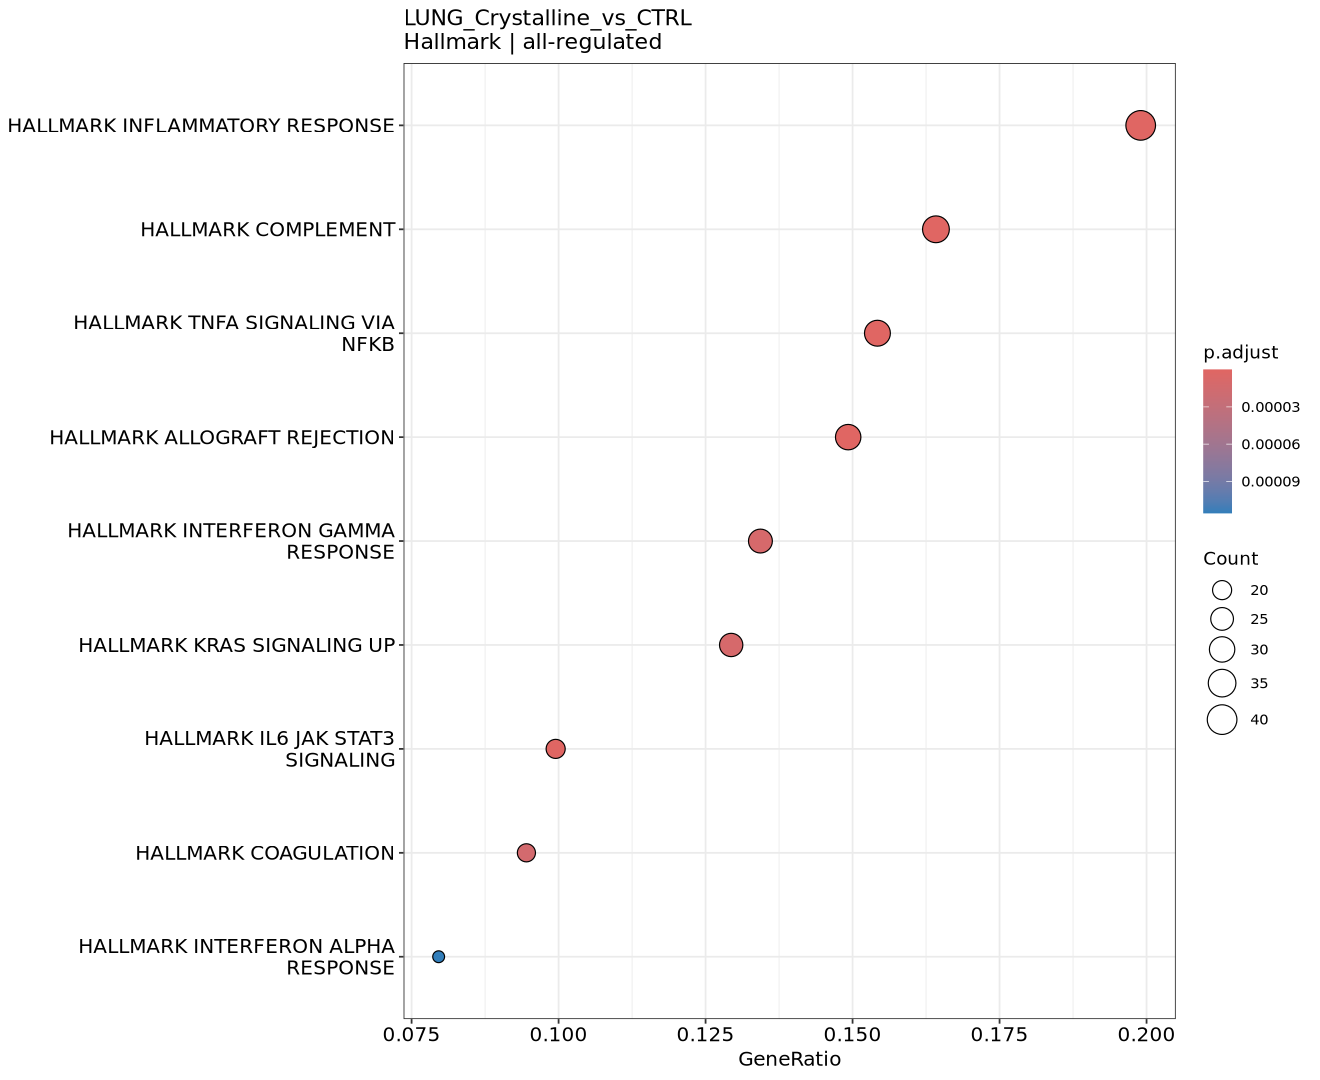

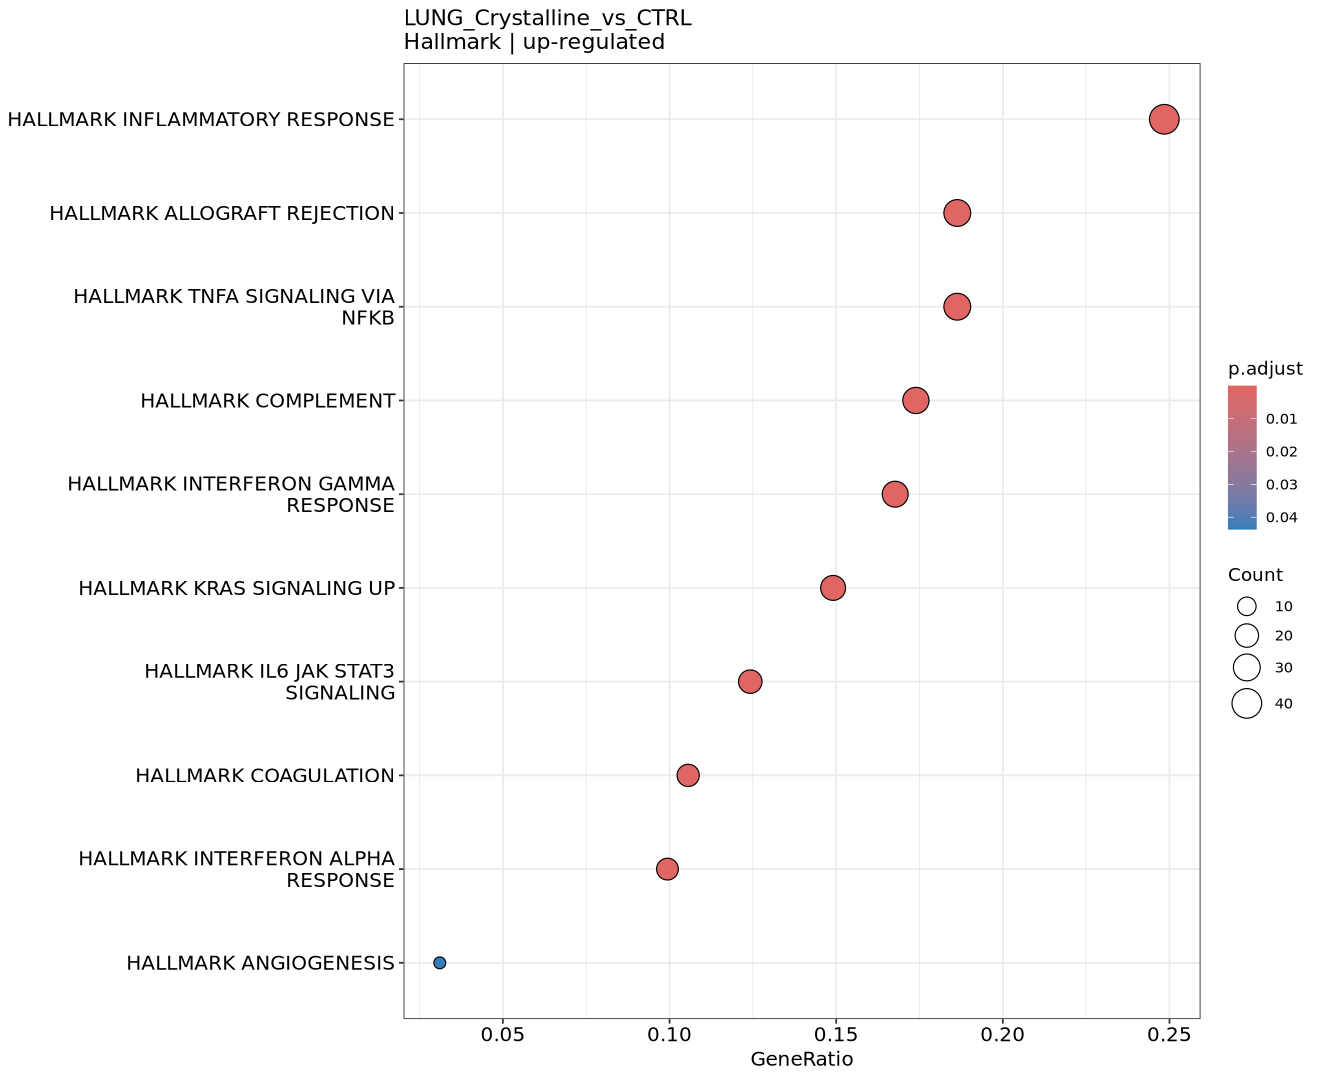

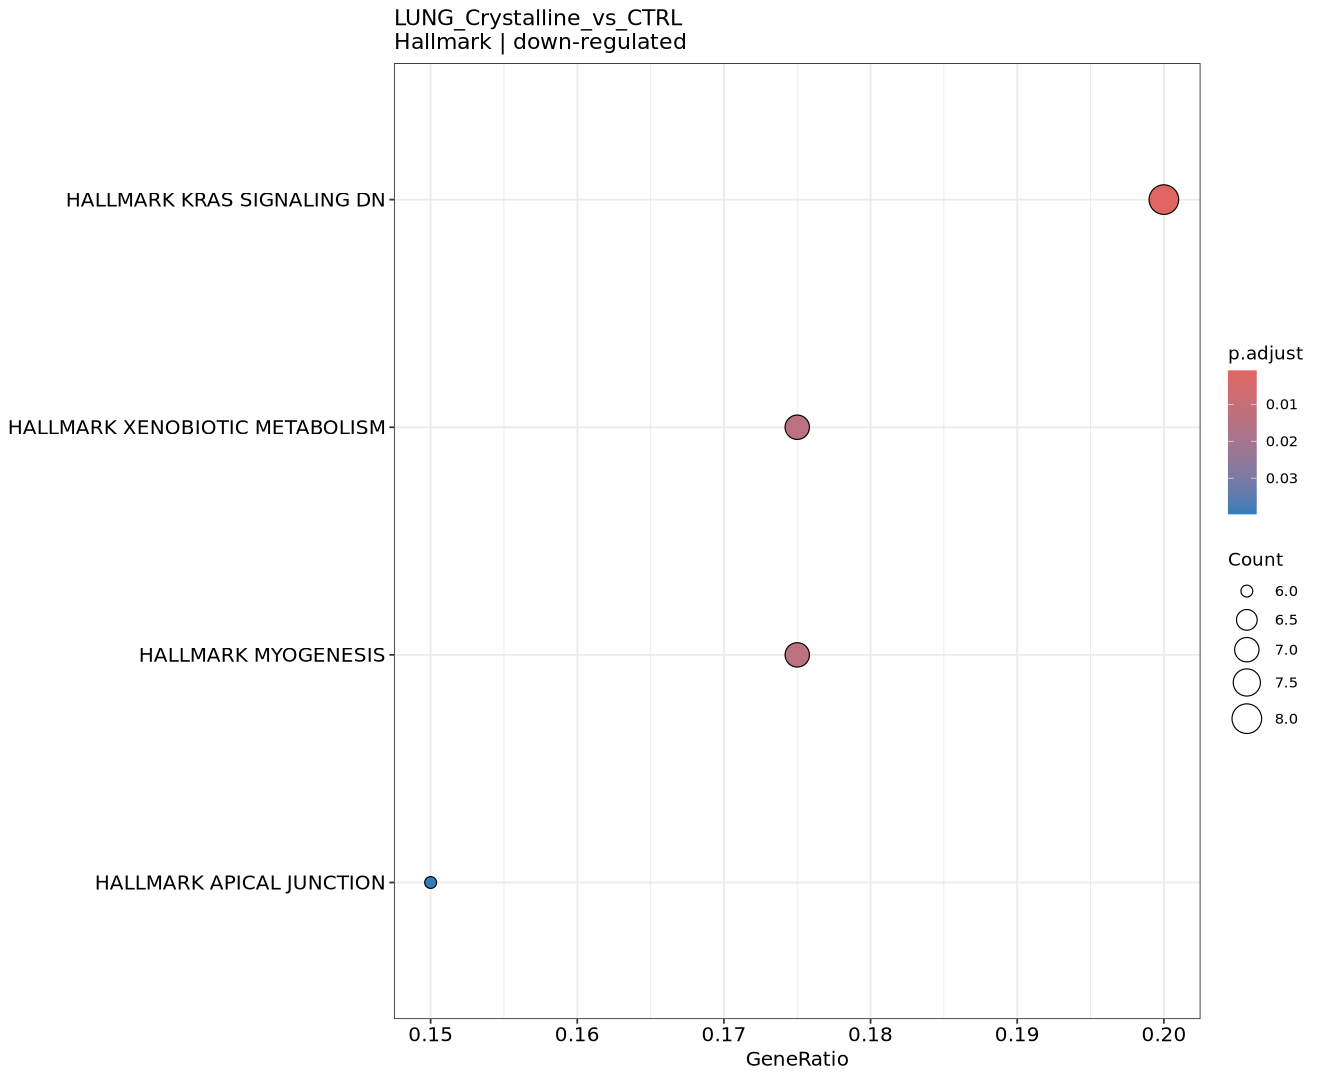

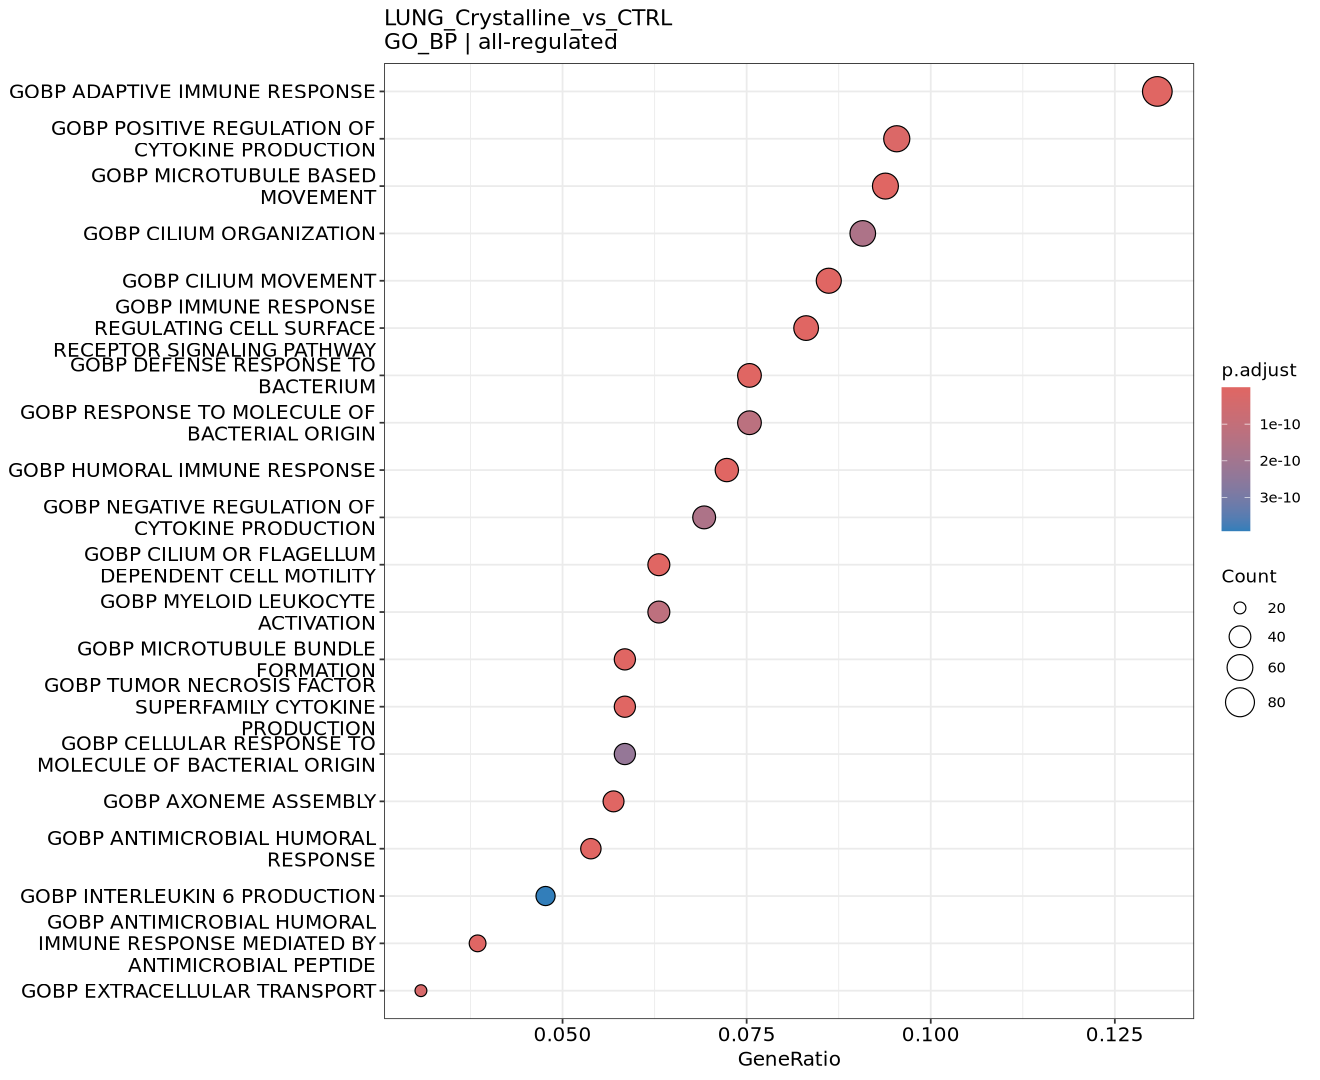

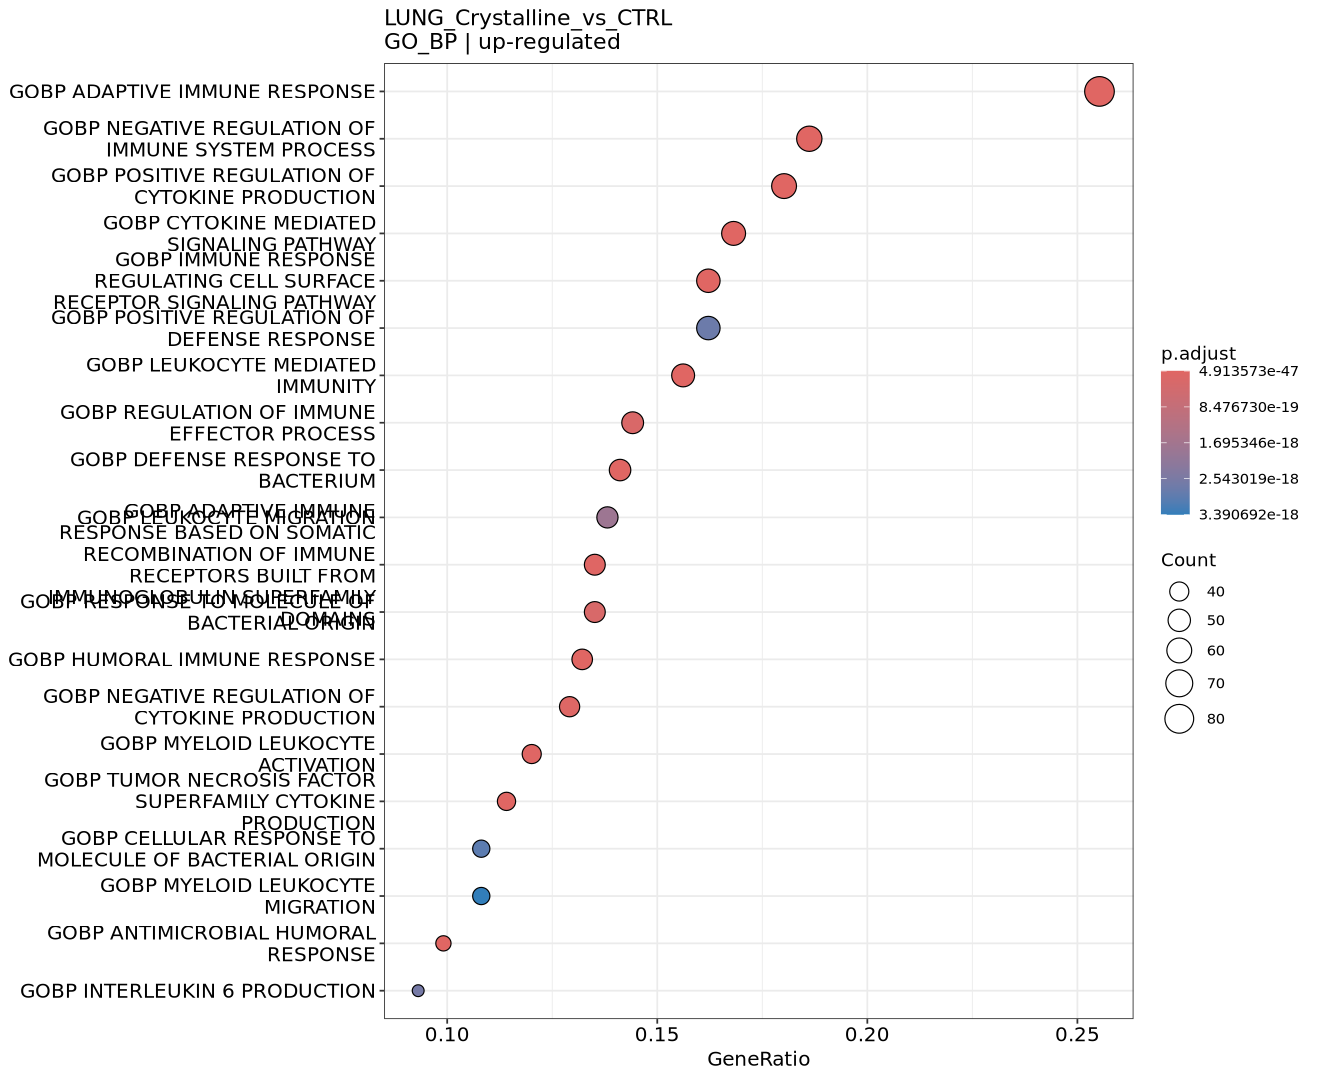

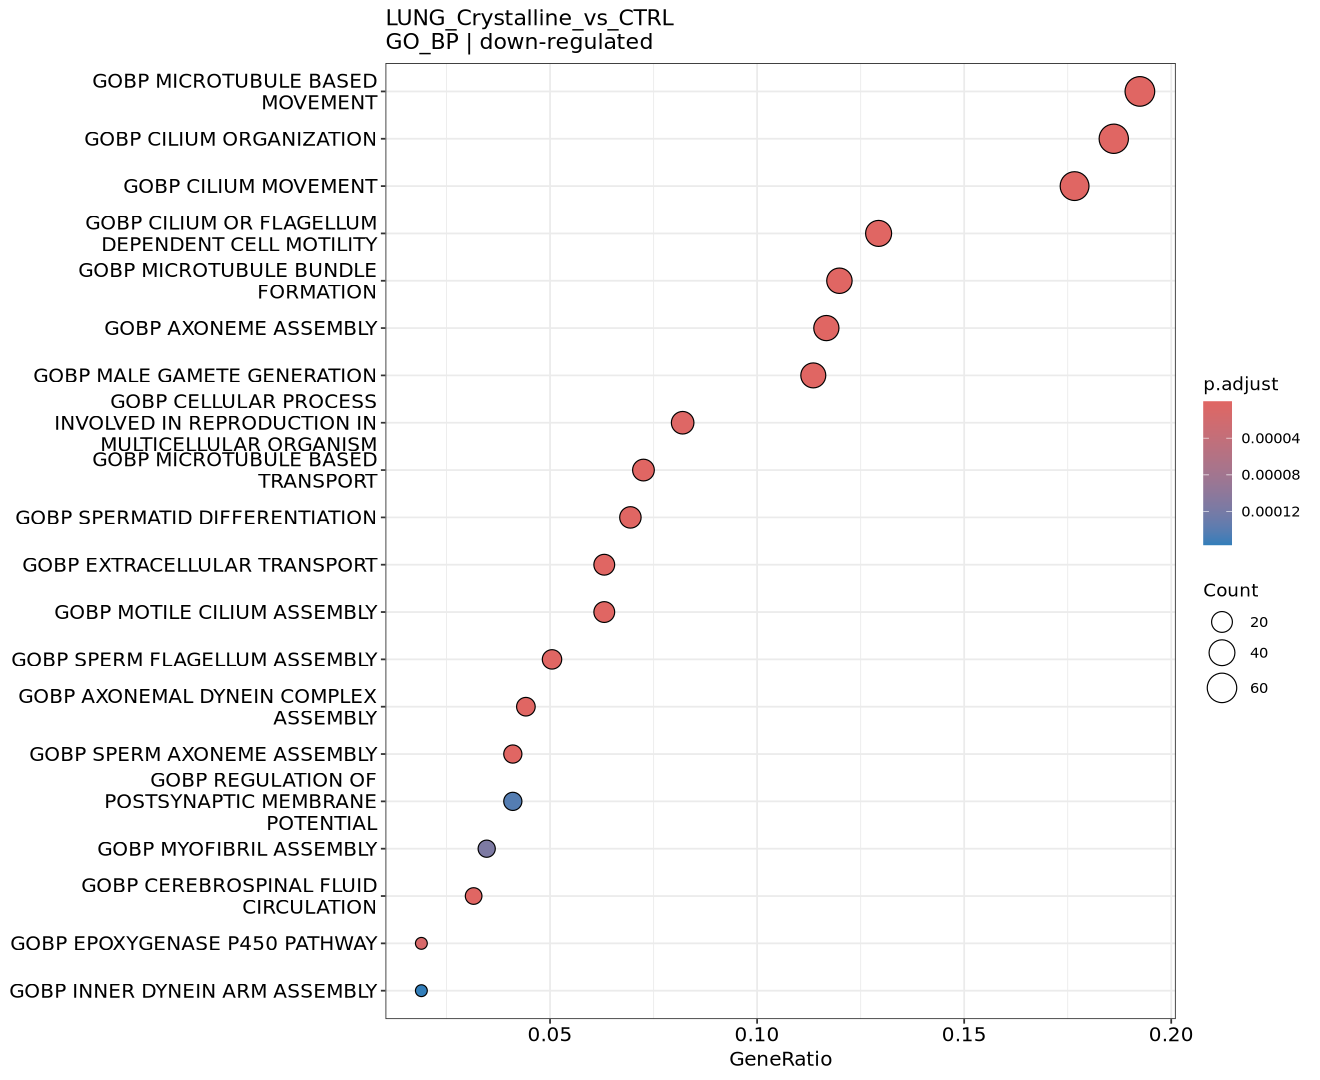

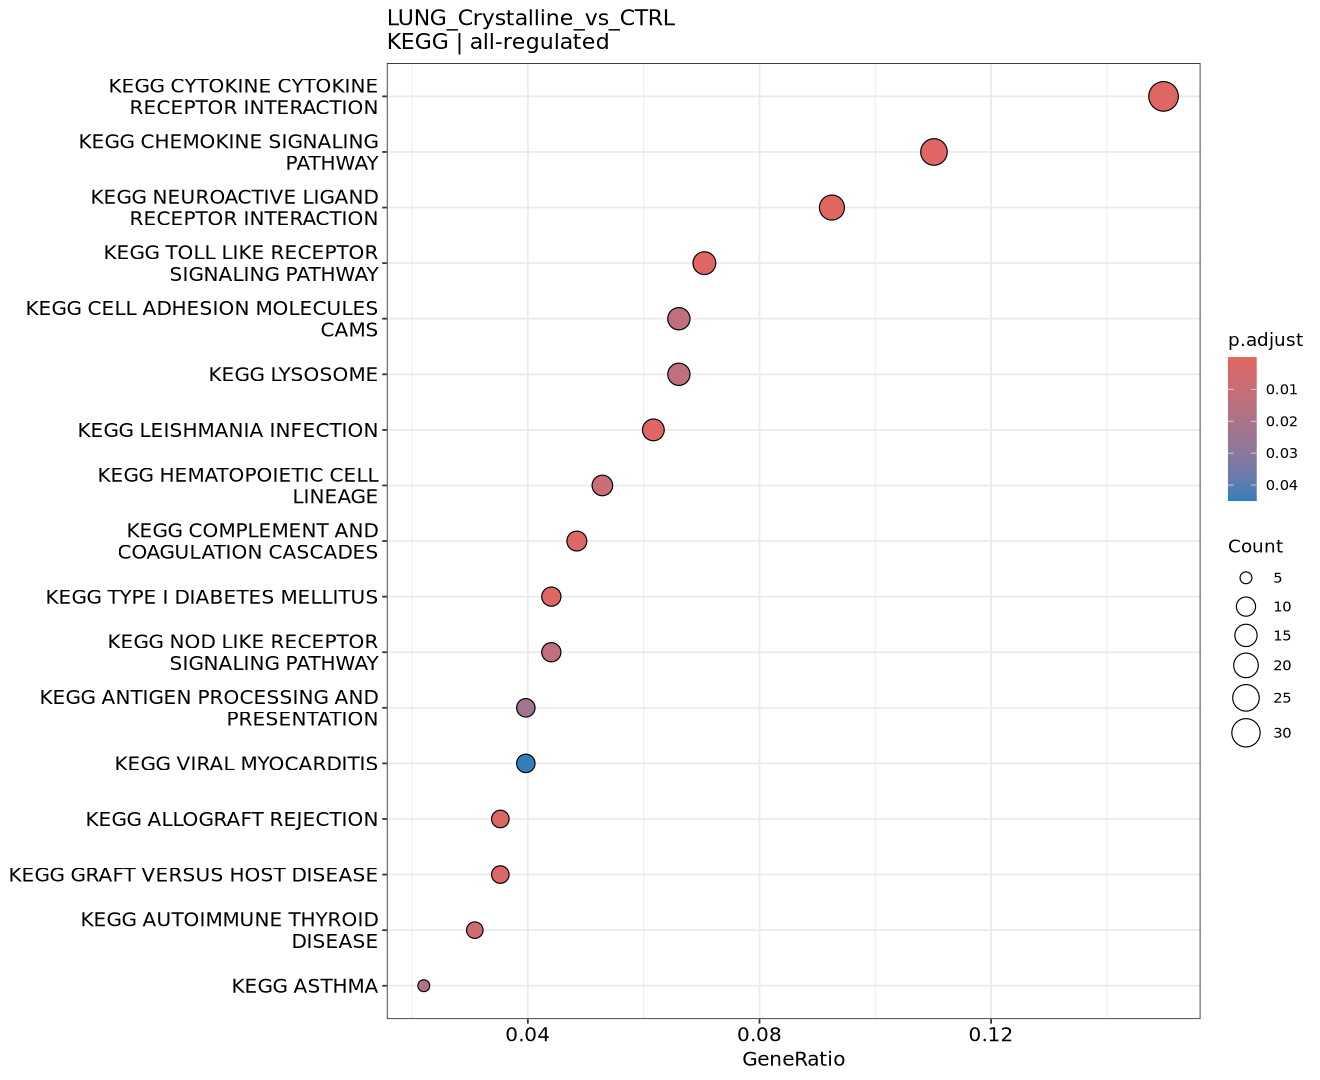

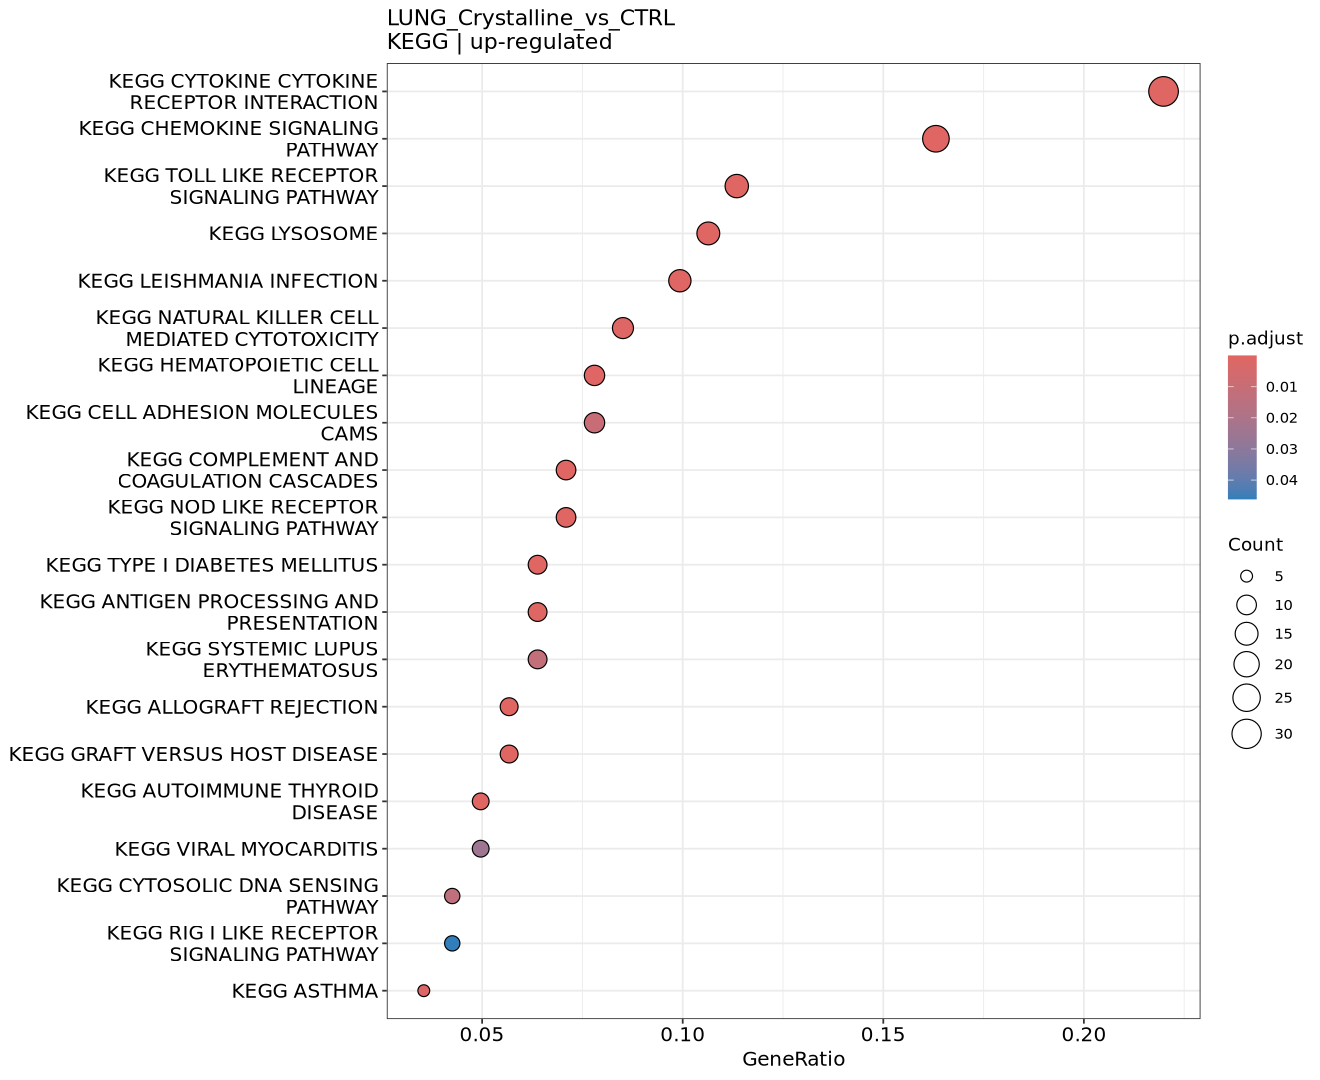

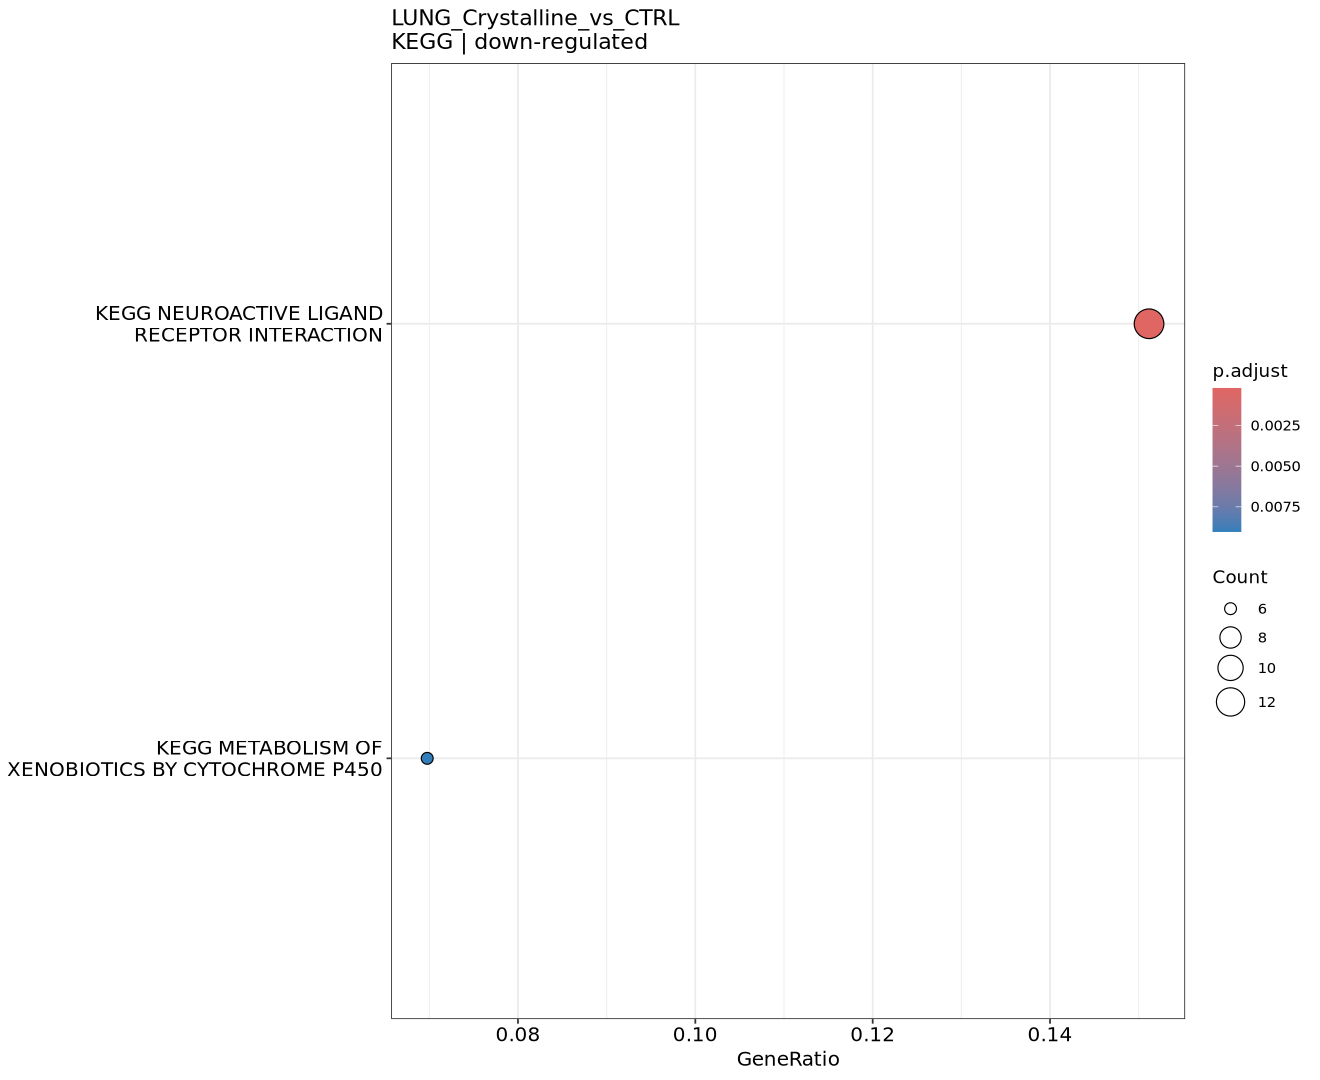

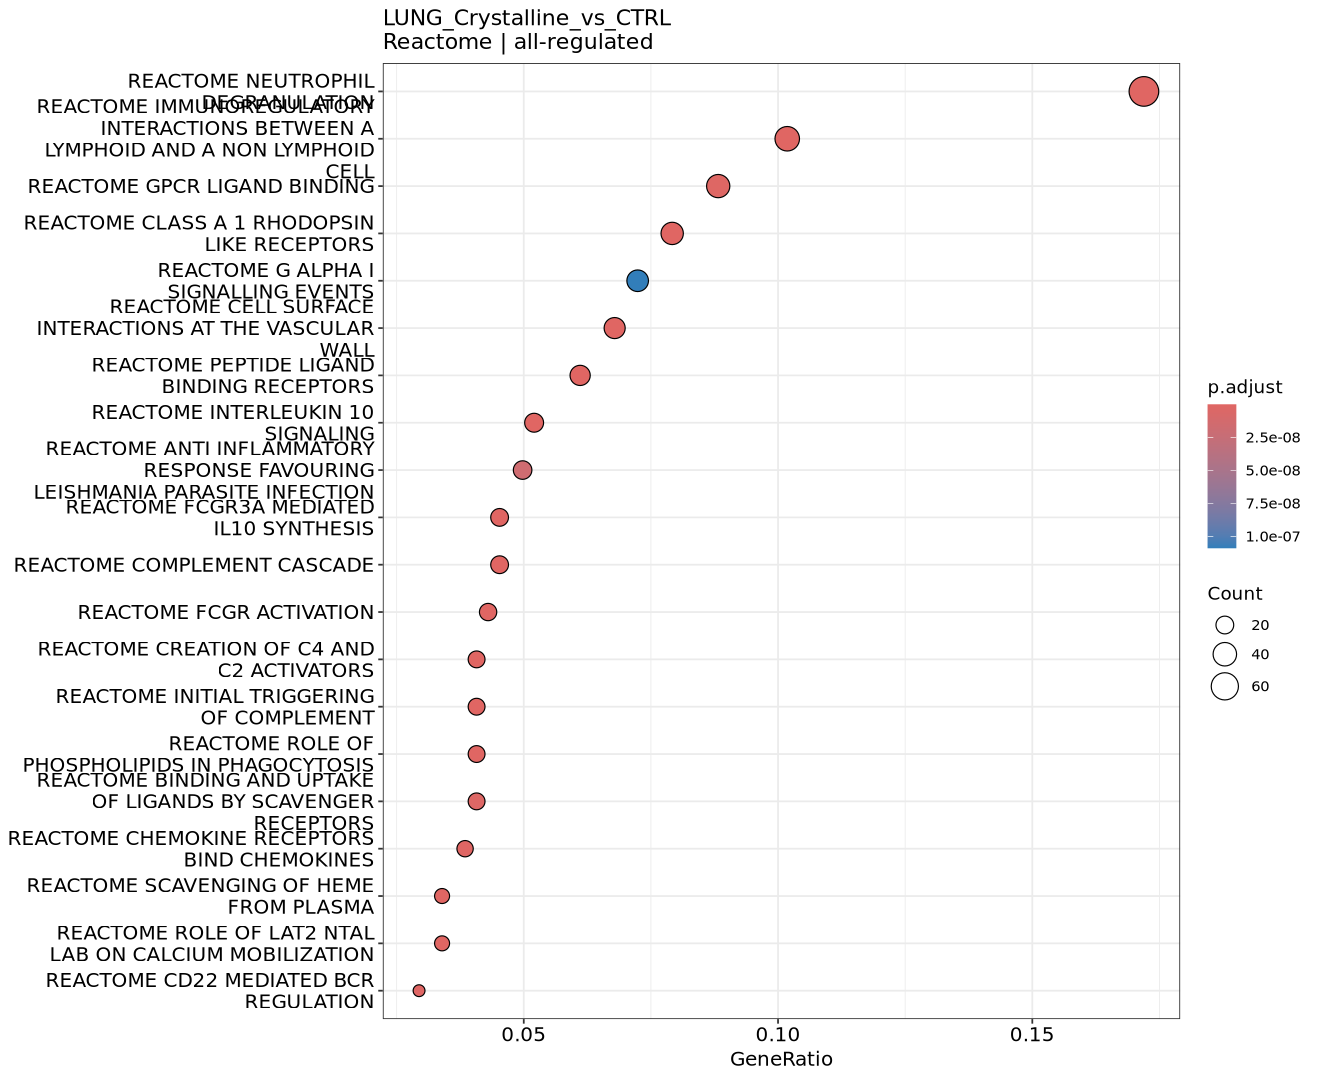

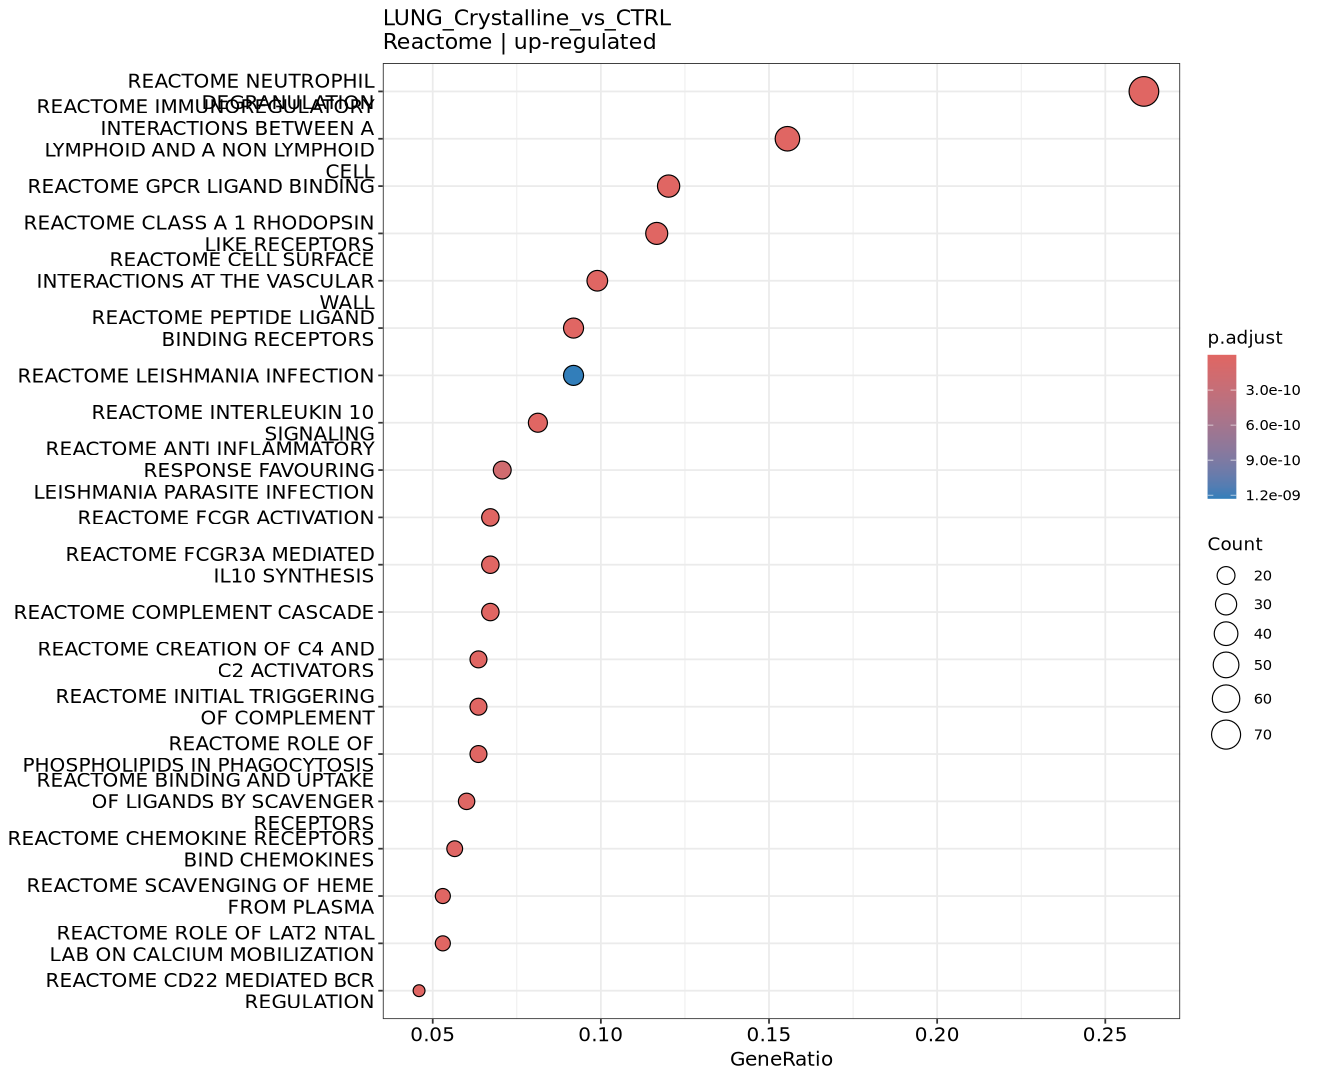

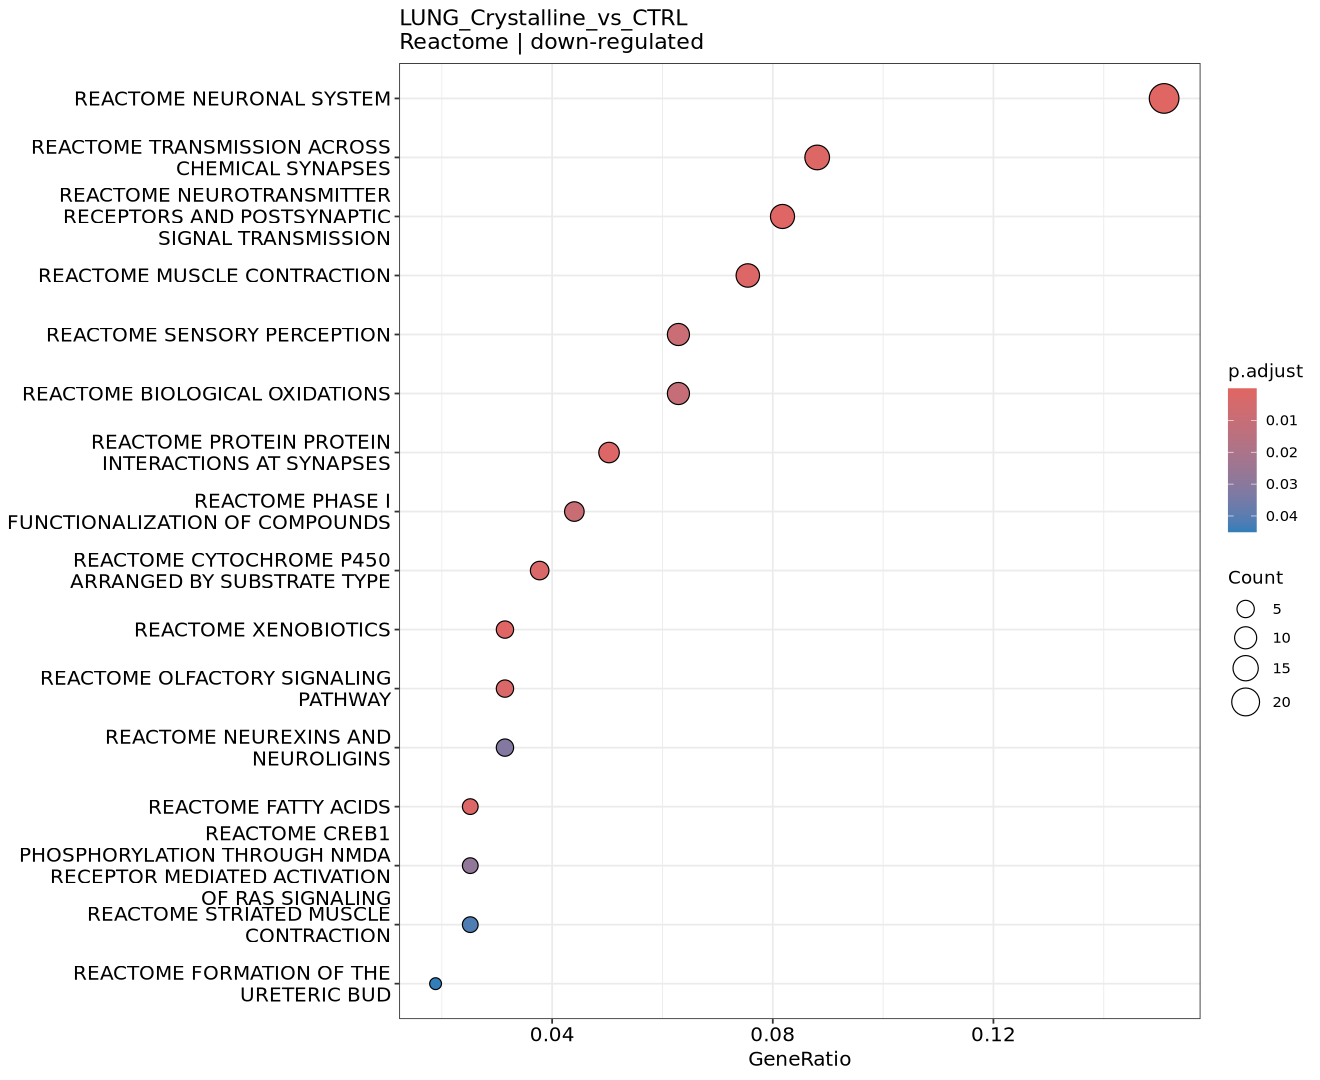

In [8]:
# Helper: walk through results and plot, skip empty
plot_all_ora_dotplots <- function(ora_results, save_dir, prefix, top_n = 20) {
  for (coll in names(ora_results)) {
    for (dir in names(ora_results[[coll]])) {
      res <- ora_results[[coll]][[dir]]
      if (is.null(res) || nrow(as.data.frame(res)) == 0) next

      title <- paste0(prefix, "\n", coll, " | ", dir, "-regulated")
      p <- plot_ora_dotplot(res, show_n = top_n, title = title)
      if (is.null(p)) next

      print(p)
      ggsave(file.path(save_dir, paste0(prefix, "_ORA_", coll, "_", dir,
                                          "_dotplot.pdf")),
             p, width = 11, height = max(6, min(14, top_n * 0.4)))
    }
  }
}

options(repr.plot.width = 11, repr.plot.height = 9)
plot_all_ora_dotplots(ora_results, PLOTS_DIR, CONTRAST_NAME, top_n = TOP_N_PATHWAYS)

### Enrichment maps

Enrichment maps cluster pathways by gene overlap, revealing higher-level themes. Most useful for the GO:BP collection (which has many overlapping terms).

Plotting enrichment map for Hallmark ...
Plotting enrichment map for GO_BP ...


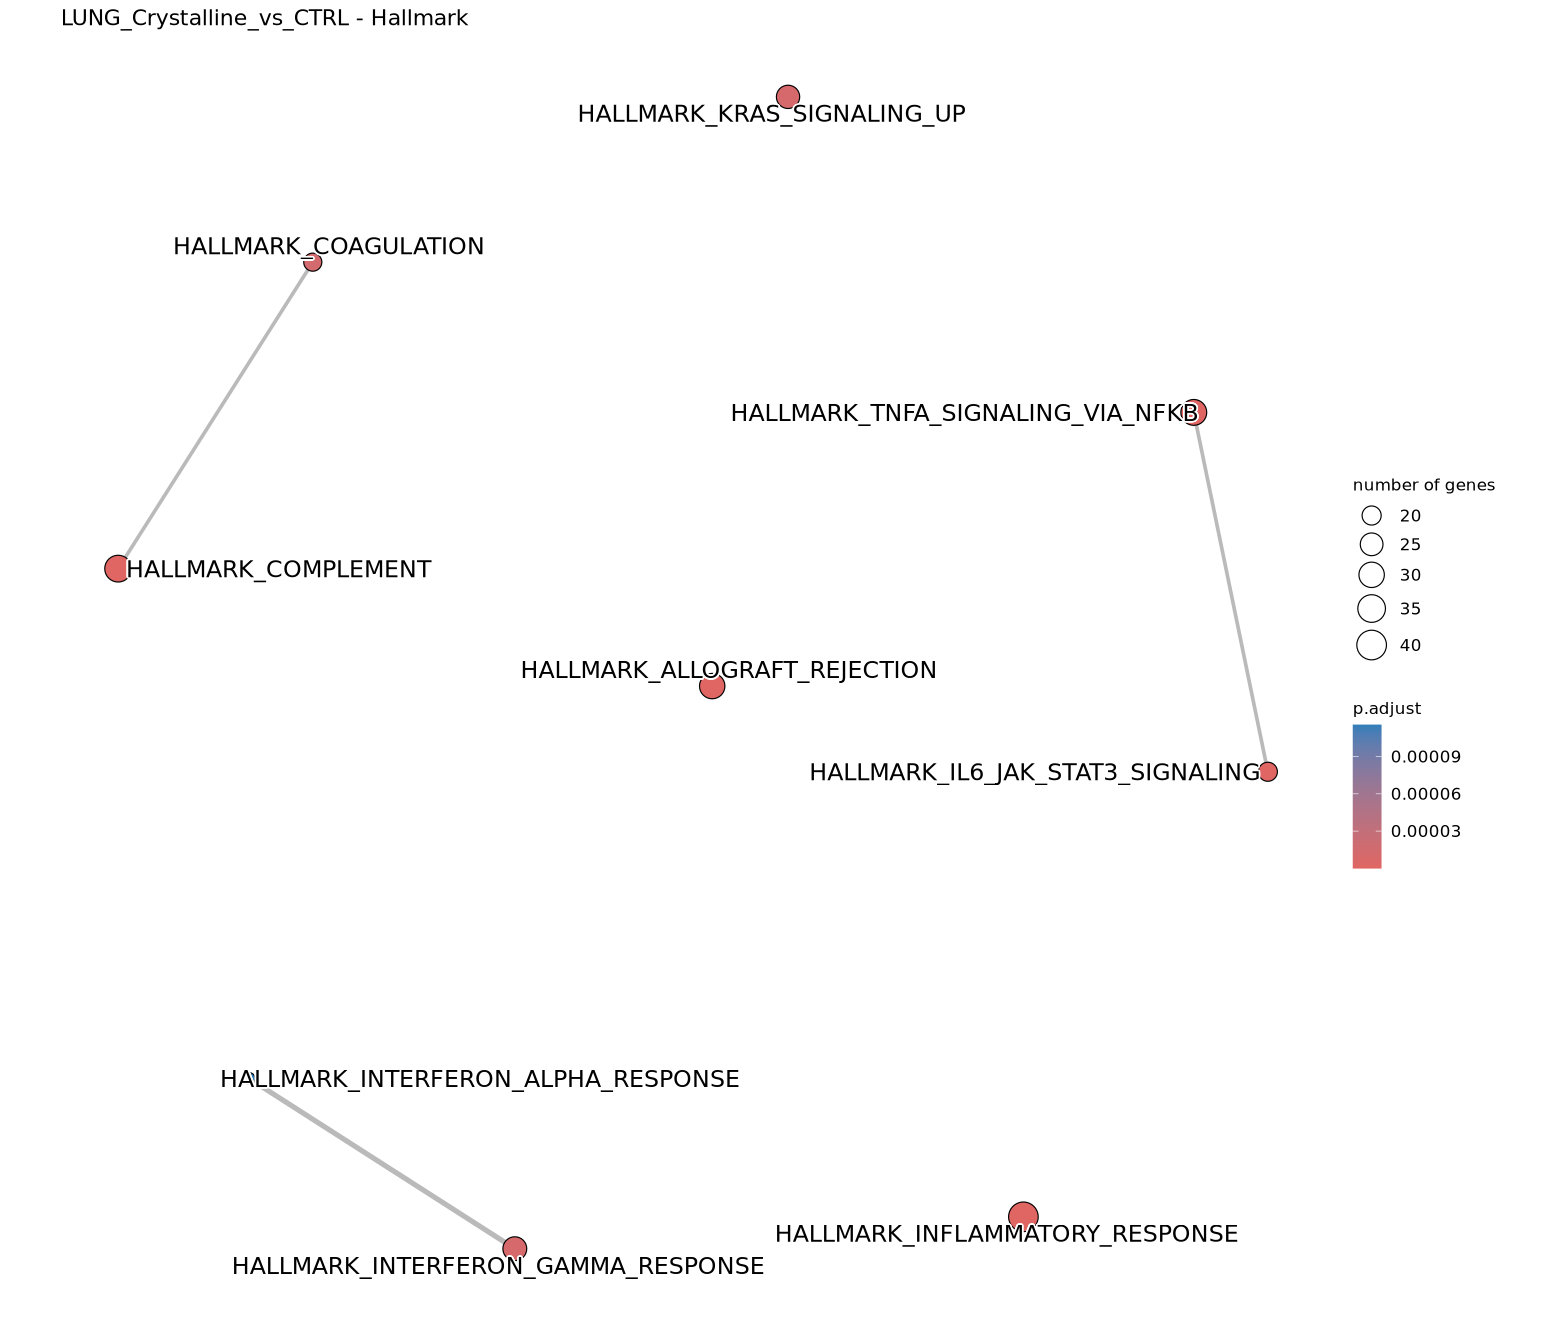

Plotting enrichment map for KEGG ...


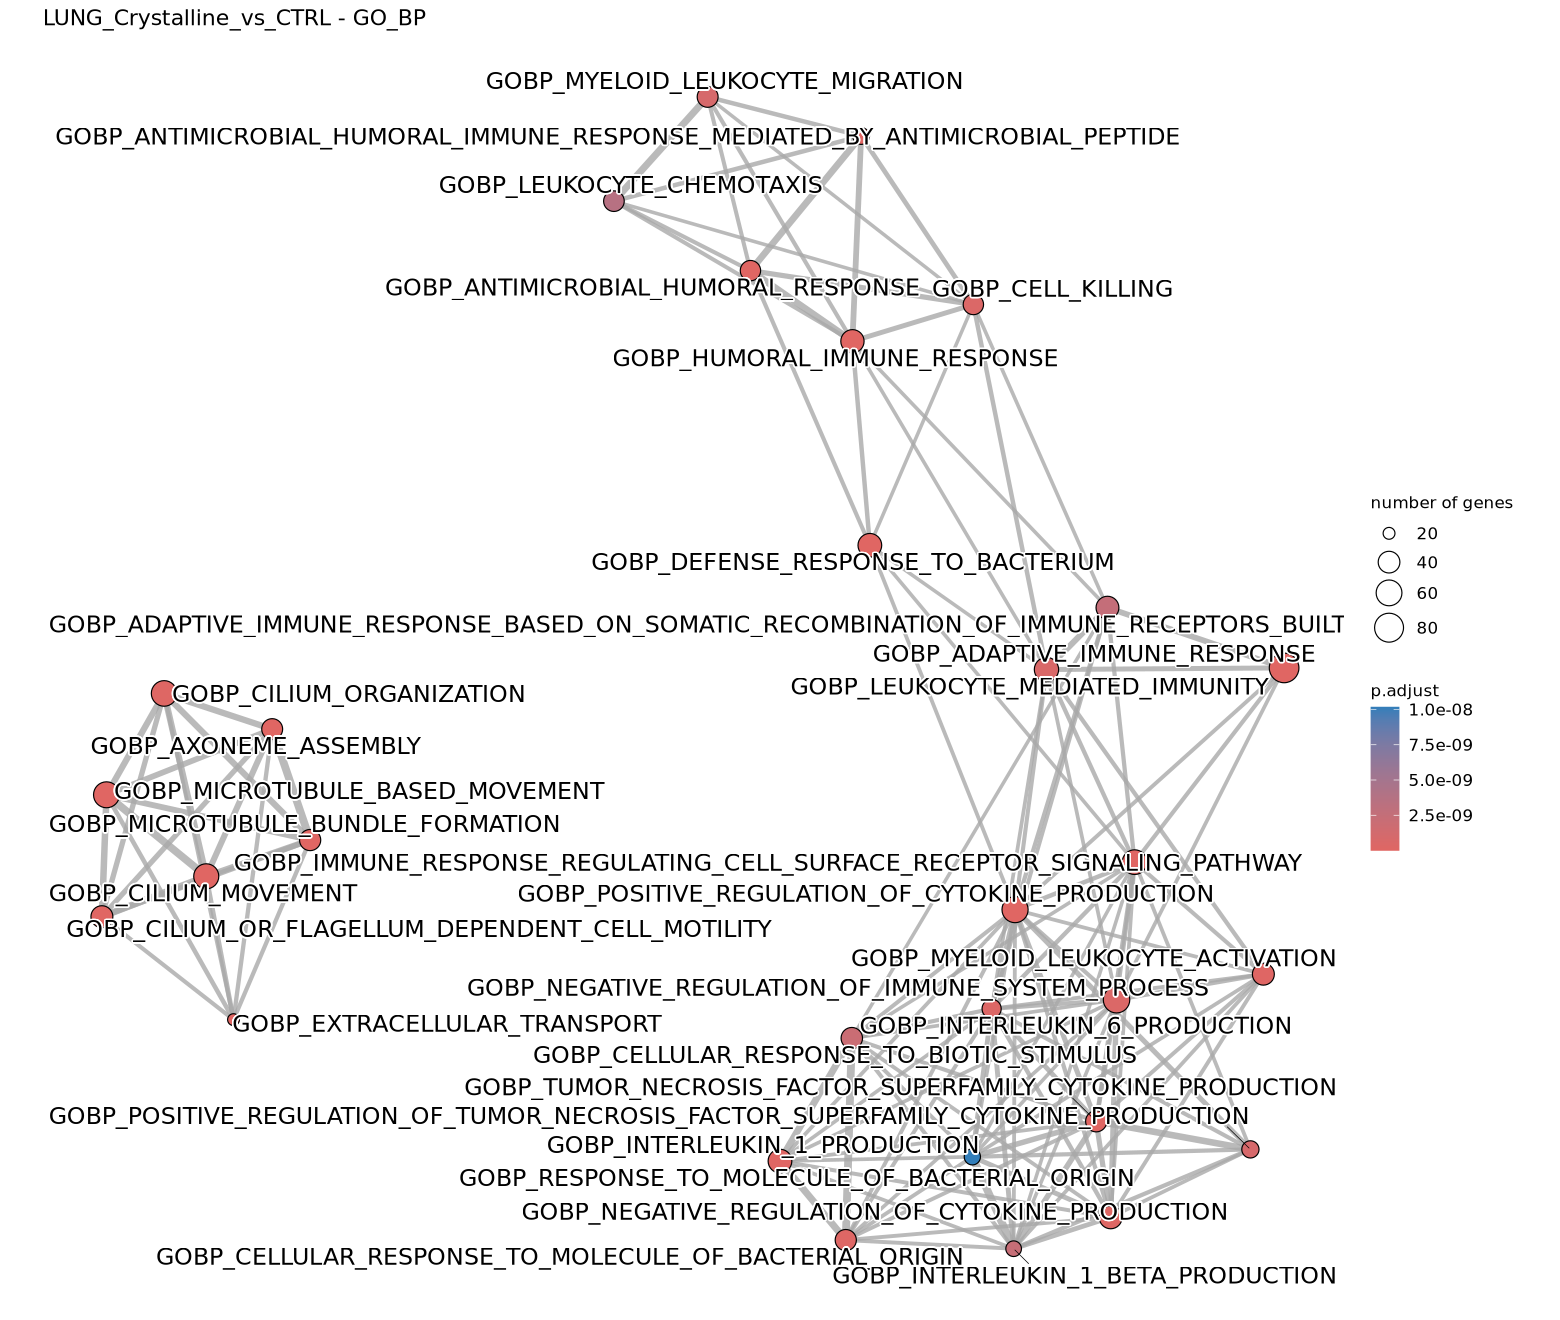

Plotting enrichment map for Reactome ...


Warning message:
“ggrepel: 14 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


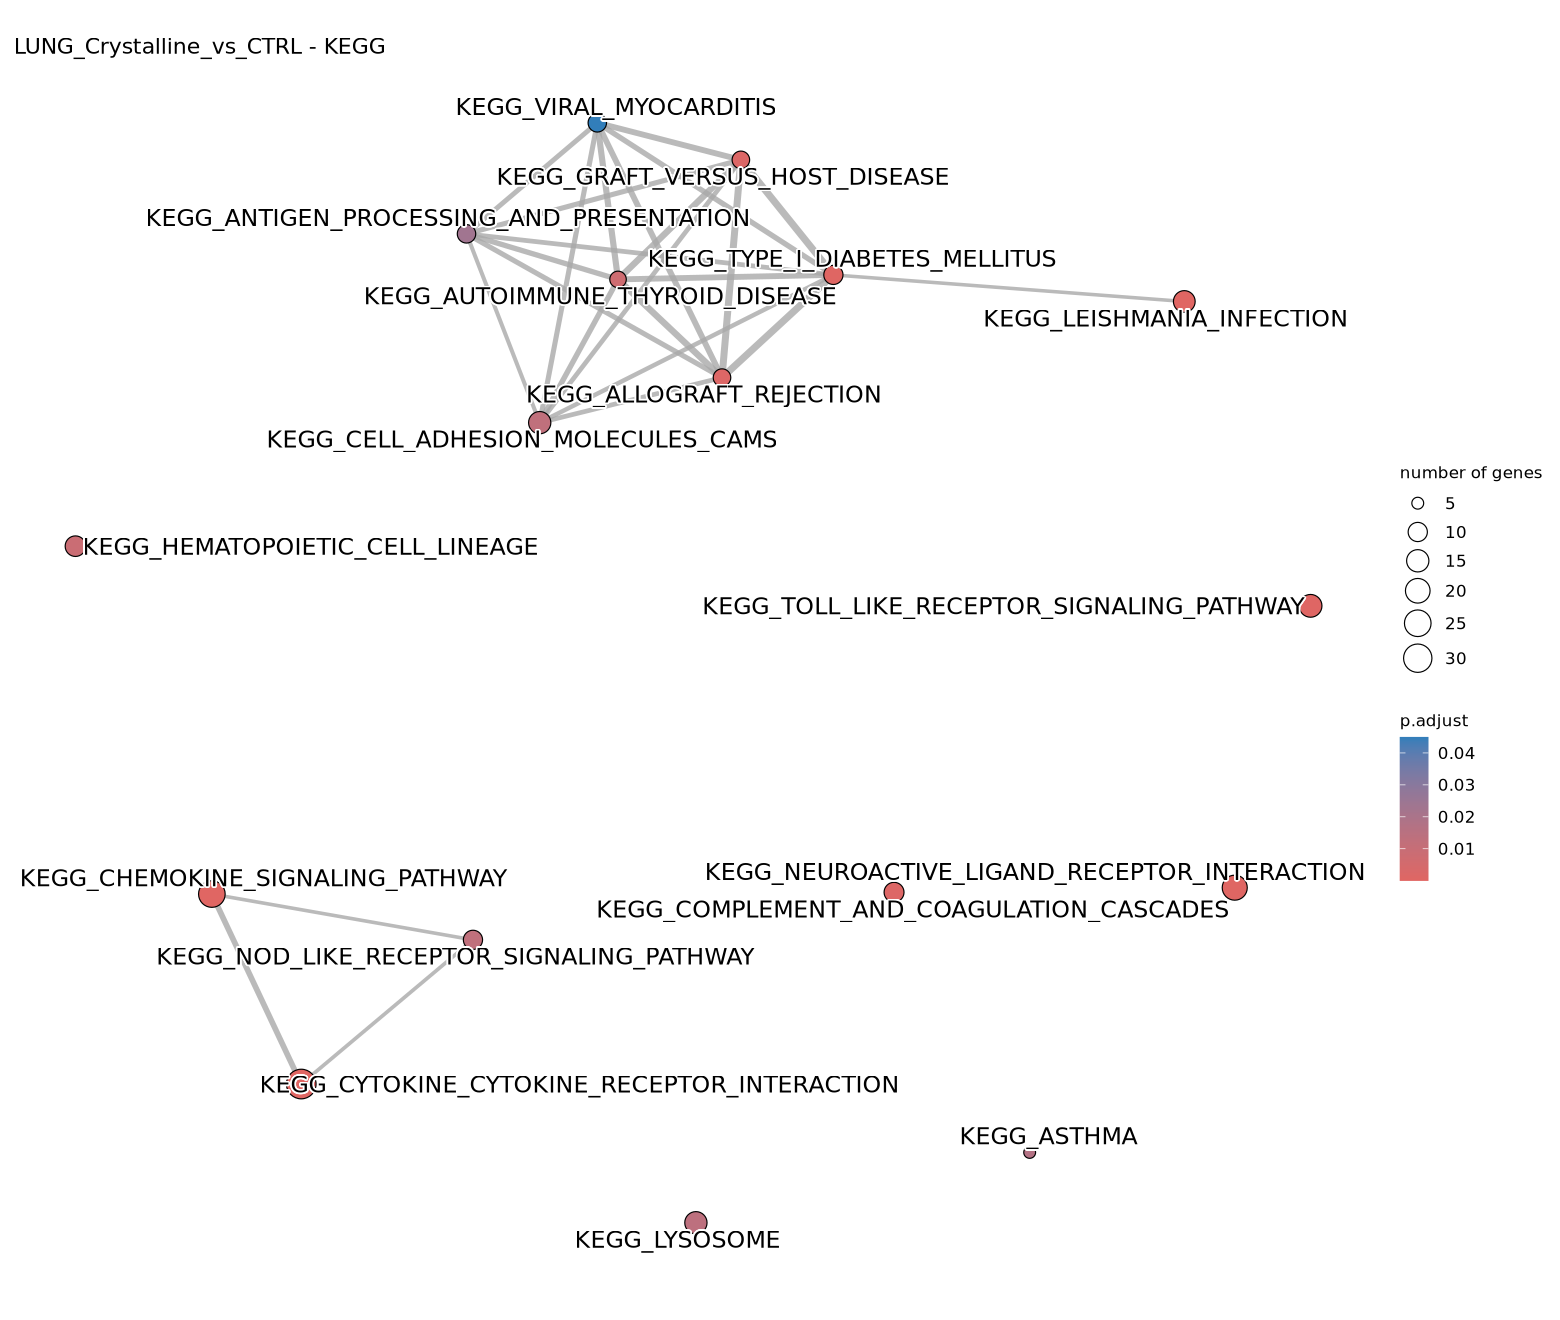

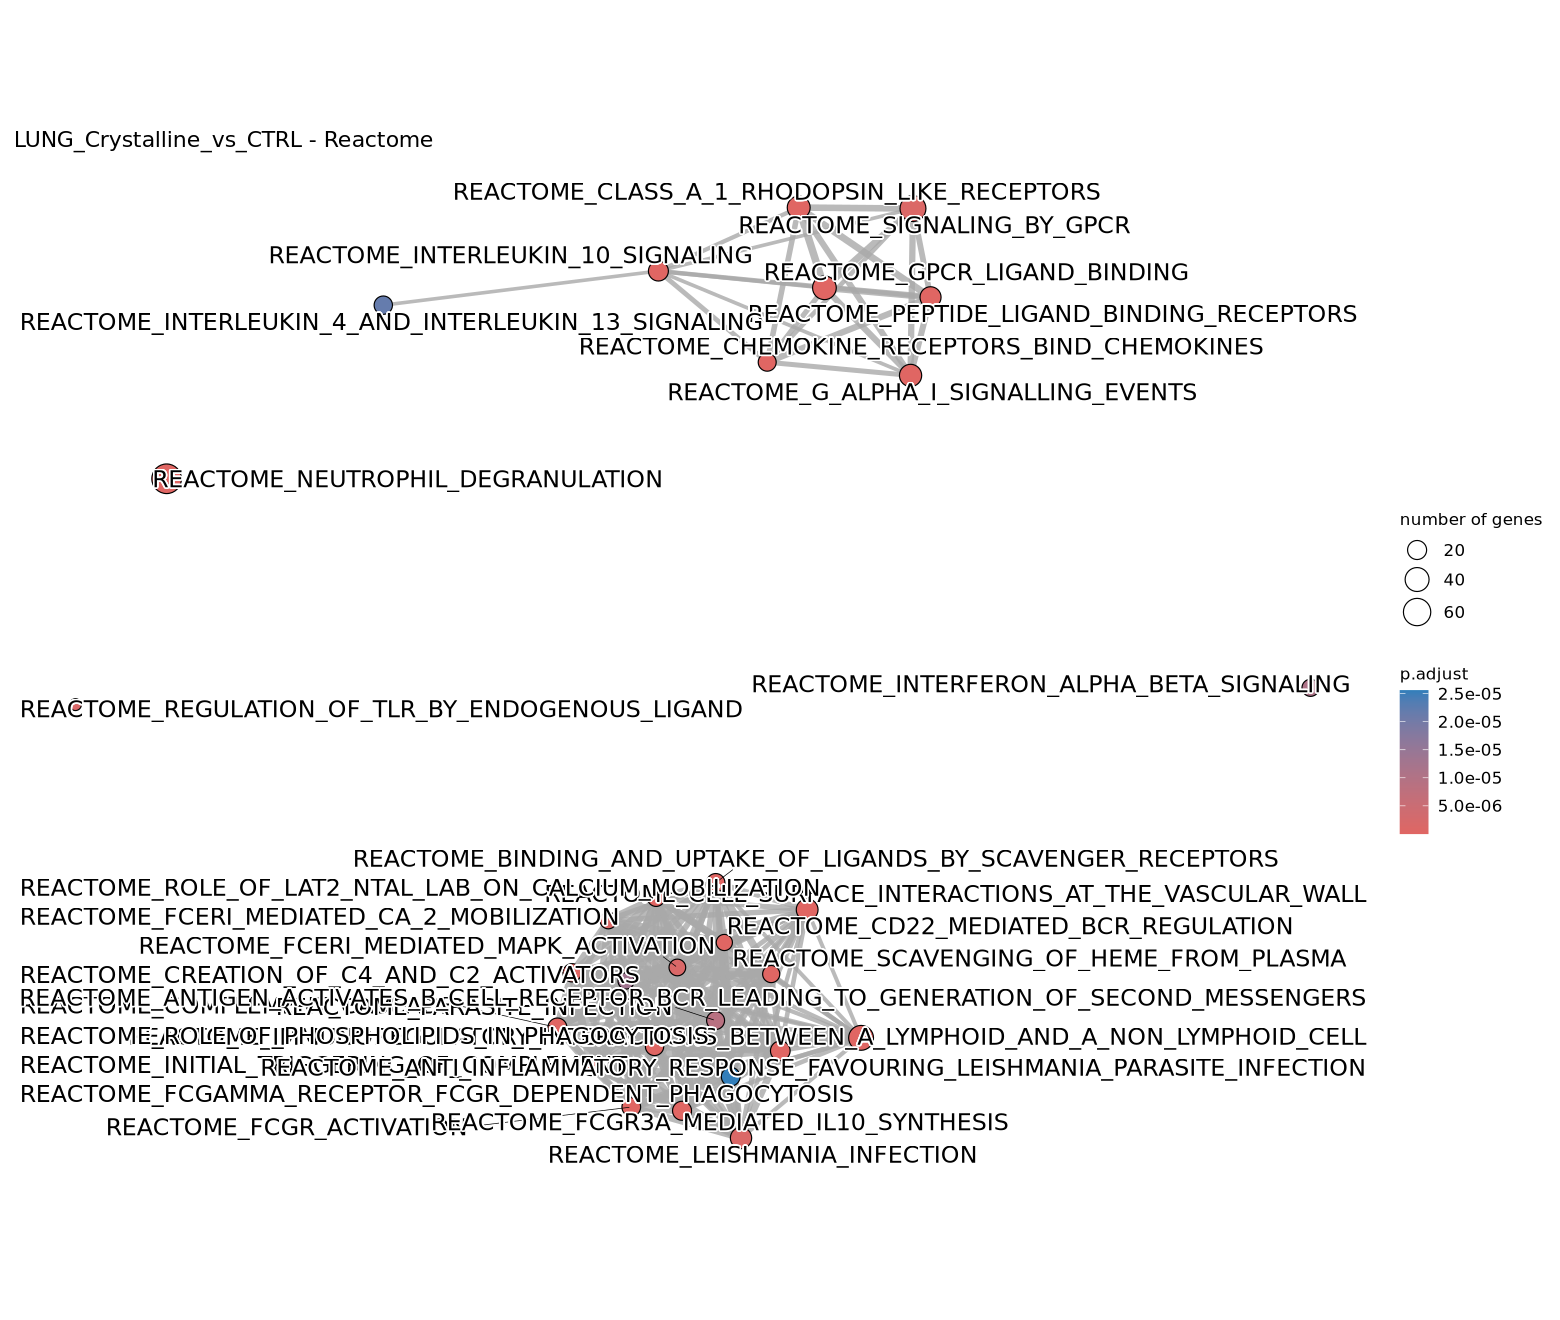

In [9]:
# Enrichment maps for "all DEGs" runs of each collection
options(repr.plot.width = 13, repr.plot.height = 11)
for (coll in names(ora_results)) {
  res <- ora_results[[coll]][["all"]]
  if (is.null(res) || nrow(as.data.frame(res)) < 5) {
    cat("Skipping", coll, "- too few results for enrichment map\n")
    next
  }
  cat("Plotting enrichment map for", coll, "...\n")
  p <- plot_ora_emap(res, show_n = 30, title = paste0(CONTRAST_NAME, " - ", coll))
  if (!is.null(p)) {
    print(p)
    ggsave(file.path(PLOTS_DIR, paste0(CONTRAST_NAME, "_ORA_", coll, "_emap.pdf")),
           p, width = 13, height = 11)
  }
}

## 8. GSEA

Runs in addition to ORA. Where ORA tests "are my DEGs over-represented in this pathway?", GSEA tests "is the pathway as a whole shifted in my data, regardless of whether individual genes pass DEG cutoffs?". The two approaches complement each other; pathways that come up in both are most robust.

In [10]:
gene_list <- prepare_gsea_input(results_df,
                                 metric = "lfc",
                                 symbol_col = "gene_name")

GSEA input prepared:
  Total ranked genes: 23692 
  Range:             -5.77 to 9.27 


In [11]:
gsea_results <- run_gsea_all_collections(
  gene_list    = gene_list,
  collections  = collections,
  padj_cutoff  = PADJ_THRESHOLD,
  min_gs_size  = 10,
  max_gs_size  = 500,
  seed         = 42
)

# Summary
cat("\n=== GSEA results per collection ===\n")
for (nm in names(gsea_results)) {
  res <- gsea_results[[nm]]
  n_sig <- if (is.null(res)) 0 else nrow(as.data.frame(res))
  n_up  <- if (is.null(res) || n_sig == 0) 0 else
           sum(as.data.frame(res)$NES > 0, na.rm = TRUE)
  n_dn  <- if (is.null(res) || n_sig == 0) 0 else
           sum(as.data.frame(res)$NES < 0, na.rm = TRUE)
  cat(sprintf("  %-10s: %4d significant  (%d activated, %d suppressed)\n",
              nm, n_sig, n_up, n_dn))
}


=== Collection: Hallmark ===
  Running GSEA ... 

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.35% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“For some pathways, in reality P-values are less than 1e-10. You can set the `eps` argument to zero for better estimation.”


   28 significant gene sets at padj < 0.05 

=== Collection: GO_BP ===
  Running GSEA ... 

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.35% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“For some pathways, in reality P-values are less than 1e-10. You can set the `eps` argument to zero for better estimation.”


   993 significant gene sets at padj < 0.05 

=== Collection: KEGG ===
  Running GSEA ... 

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.35% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“For some pathways, in reality P-values are less than 1e-10. You can set the `eps` argument to zero for better estimation.”


   44 significant gene sets at padj < 0.05 

=== Collection: Reactome ===
  Running GSEA ... 

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.35% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“For some pathways, in reality P-values are less than 1e-10. You can set the `eps` argument to zero for better estimation.”


   228 significant gene sets at padj < 0.05 

=== GSEA results per collection ===
  Hallmark  :   28 significant  (26 activated, 2 suppressed)
  GO_BP     :  993 significant  (884 activated, 109 suppressed)
  KEGG      :   44 significant  (39 activated, 5 suppressed)
  Reactome  :  228 significant  (208 activated, 20 suppressed)


In [12]:
# Save all GSEA results
save_all_gsea_results(gsea_results, OUTPUT_DIR, CONTRAST_NAME)

  Saved LUNG_Crystalline_vs_CTRL_GSEA_Hallmark ( 28 rows)
  Saved LUNG_Crystalline_vs_CTRL_GSEA_GO_BP ( 993 rows)
  Saved LUNG_Crystalline_vs_CTRL_GSEA_KEGG ( 44 rows)
  Saved LUNG_Crystalline_vs_CTRL_GSEA_Reactome ( 228 rows)


## 8b. DEG × Hallmark overlap (pick genes to label on the volcano)

For each Hallmark pathway, this lists which of my DEGs (|log2FC| >= `LFC_THRESHOLD`
and `padj` < `PADJ_THRESHOLD`) are members of that pathway's gene set. The idea is
to prioritise labelling genes that are both differentially expressed **and** part
of a biologically meaningful pathway.

- `hallmark_deg_overlap` : long table (one row per DEG × pathway membership).
- `deg_pathway_summary`  : one row per DEG, with how many Hallmark pathways it
  drives and which ones — sort/scan this to build your label list.

Nothing here changes the analysis; it only produces tables to inform which gene
symbols you hand to the volcano plot in notebook `01`.

In [13]:
# === DEG x Hallmark overlap ==================================================
# Uses results_df (loaded above) and the Hallmark collection in `collections`.

suppressPackageStartupMessages(library(dplyr))

hallmark_tbl <- collections[["Hallmark"]]

# msigdbr column names vary by version; auto-detect the gene-symbol column.
sym_candidates <- c("gene_symbol", "mouse_gene_symbol", "symbol",
                    "gene_name", "ortholog_symbol")
gene_col <- sym_candidates[sym_candidates %in% colnames(hallmark_tbl)][1]
set_col  <- if ("gs_name" %in% colnames(hallmark_tbl)) "gs_name" else
            colnames(hallmark_tbl)[grepl("gs_name|pathway|set", colnames(hallmark_tbl))][1]
stopifnot(!is.na(gene_col), !is.na(set_col))
cat("Using Hallmark gene column:", gene_col, "| set column:", set_col, "\n")

# 1. Define the DEG set from the DESeq2 results.
deg_df <- results_df %>%
  filter(!is.na(padj),
         padj < PADJ_THRESHOLD,
         abs(log2FoldChange) >= LFC_THRESHOLD) %>%
  mutate(direction = ifelse(log2FoldChange > 0, "up", "down")) %>%
  select(gene_name, log2FoldChange, padj, direction)

cat("DEGs (|LFC| >=", LFC_THRESHOLD, "& padj <", PADJ_THRESHOLD, "):",
    nrow(deg_df), "\n")

# 2. Hallmark membership table, keyed on symbol.
hallmark_membership <- hallmark_tbl %>%
  transmute(pathway = .data[[set_col]],
            gene_name = .data[[gene_col]]) %>%
  distinct()

# 3. Long overlap: one row per (DEG, pathway) membership.
hallmark_deg_overlap <- deg_df %>%
  inner_join(hallmark_membership, by = "gene_name") %>%
  arrange(desc(abs(log2FoldChange)), gene_name, pathway)

cat("DEGs that appear in >=1 Hallmark pathway:",
    dplyr::n_distinct(hallmark_deg_overlap$gene_name), "\n")
cat("DEG x pathway membership rows:", nrow(hallmark_deg_overlap), "\n\n")

# 4. Per-gene summary: how many Hallmark pathways each DEG drives.
deg_pathway_summary <- hallmark_deg_overlap %>%
  group_by(gene_name, log2FoldChange, padj, direction) %>%
  summarise(n_hallmark_pathways = dplyr::n(),
            hallmark_pathways = paste(sort(unique(pathway)), collapse = "; "),
            .groups = "drop") %>%
  arrange(desc(n_hallmark_pathways), padj)

cat("=== Top DEGs by number of Hallmark pathways they belong to ===\n")
print(head(as.data.frame(deg_pathway_summary), 30))

# 5. DEGs that are NOT in any Hallmark pathway (for reference).
degs_no_hallmark <- deg_df %>%
  filter(!gene_name %in% hallmark_deg_overlap$gene_name) %>%
  arrange(padj)
cat("\nDEGs NOT in any Hallmark pathway:", nrow(degs_no_hallmark), "\n")

# 6. Save both tables so you can browse them / build the label list.
overlap_dir <- file.path(OUTPUT_DIR, "deg_hallmark_overlap")
dir.create(overlap_dir, recursive = TRUE, showWarnings = FALSE)
write.csv(hallmark_deg_overlap,
          file.path(overlap_dir, paste0(CONTRAST_NAME, "_DEG_hallmark_long.csv")),
          row.names = FALSE)
write.csv(deg_pathway_summary,
          file.path(overlap_dir, paste0(CONTRAST_NAME, "_DEG_hallmark_summary.csv")),
          row.names = FALSE)
cat("\nSaved overlap tables to:", overlap_dir, "\n")

# --- Optional: restrict to Hallmark pathways that were significant in GSEA -----
# Often you only care about drivers of pathways that actually came up as
# enriched. Uncomment to filter the summary to genes in GSEA-significant
# Hallmark pathways only.
#
# sig_hallmark <- as.data.frame(gsea_results[["Hallmark"]])$ID
# deg_pathway_summary_sig <- hallmark_deg_overlap %>%
#   filter(pathway %in% sig_hallmark) %>%
#   group_by(gene_name, log2FoldChange, padj, direction) %>%
#   summarise(n_sig_hallmark = dplyr::n(),
#             sig_hallmark_pathways = paste(sort(unique(pathway)), collapse = "; "),
#             .groups = "drop") %>%
#   arrange(desc(n_sig_hallmark), padj)
# print(head(as.data.frame(deg_pathway_summary_sig), 30))


Using Hallmark gene column: gene_symbol | set column: gs_name 
DEGs (|LFC| >= 1.5 & padj < 0.05 ): 1289 
DEGs that appear in >=1 Hallmark pathway: 201 
DEG x pathway membership rows: 415 

=== Top DEGs by number of Hallmark pathways they belong to ===
   gene_name log2FoldChange         padj direction n_hallmark_pathways
1      Plaur       1.518215 1.821130e-04        up                   8
2      Timp1       2.115359 2.714967e-06        up                   7
3     Cxcl10       2.465024 7.657833e-04        up                   7
4    Tnfaip3       1.698396 9.495859e-27        up                   6
5       Il1b       3.241437 8.066952e-19        up                   6
6      Hmox1       2.069921 6.258515e-04        up                   6
7       Ccl2       5.089135 2.309621e-26        up                   5
8      Cxcl1       4.274324 1.091498e-16        up                   5
9       Irf7       1.724975 1.809362e-09        up                   5
10     Inhba       2.421724 1.230240e-

In [14]:
# === Pathway-driver gene tables (Panther-style supplemental) ===
DRIVER_OUTPUT_DIR <- file.path(OUTPUT_DIR, "pathway_driver_tables")
dir.create(DRIVER_OUTPUT_DIR, recursive = TRUE, showWarnings = FALSE)

out_xlsx <- file.path(DRIVER_OUTPUT_DIR,
                      paste0(CONTRAST_NAME, "_pathway_drivers.xlsx"))

write_pathway_driver_workbook(
  gsea_results = gsea_results,
  ora_results  = ora_results,
  output_path  = out_xlsx,
  max_pathways_per_sheet = 50
)

  Wrote sheet: GSEA_Hallmark ( 28 pathways)
  Wrote sheet: GSEA_GO_BP ( 50 pathways)
  Wrote sheet: GSEA_KEGG ( 44 pathways)
  Wrote sheet: GSEA_Reactome ( 50 pathways)
  Wrote sheet: ORA_Hallmark_all ( 9 pathways)
  Wrote sheet: ORA_Hallmark_up ( 10 pathways)
  Wrote sheet: ORA_Hallmark_down ( 4 pathways)
  Wrote sheet: ORA_GO_BP_all ( 50 pathways)
  Wrote sheet: ORA_GO_BP_up ( 50 pathways)
  Wrote sheet: ORA_GO_BP_down ( 50 pathways)
  Wrote sheet: ORA_KEGG_all ( 17 pathways)
  Wrote sheet: ORA_KEGG_up ( 20 pathways)
  Wrote sheet: ORA_KEGG_down ( 2 pathways)
  Wrote sheet: ORA_Reactome_all ( 50 pathways)
  Wrote sheet: ORA_Reactome_up ( 50 pathways)
  Wrote sheet: ORA_Reactome_down ( 16 pathways)

Saved pathway-driver workbook: enrichment_lung/pathway_driver_tables/LUNG_Crystalline_vs_CTRL_pathway_drivers.xlsx 


### GSEA dotplots

Activated pathways (NES > 0, enriched at top of ranked list = upregulated) and Suppressed pathways (NES < 0, downregulated) shown side-by-side.

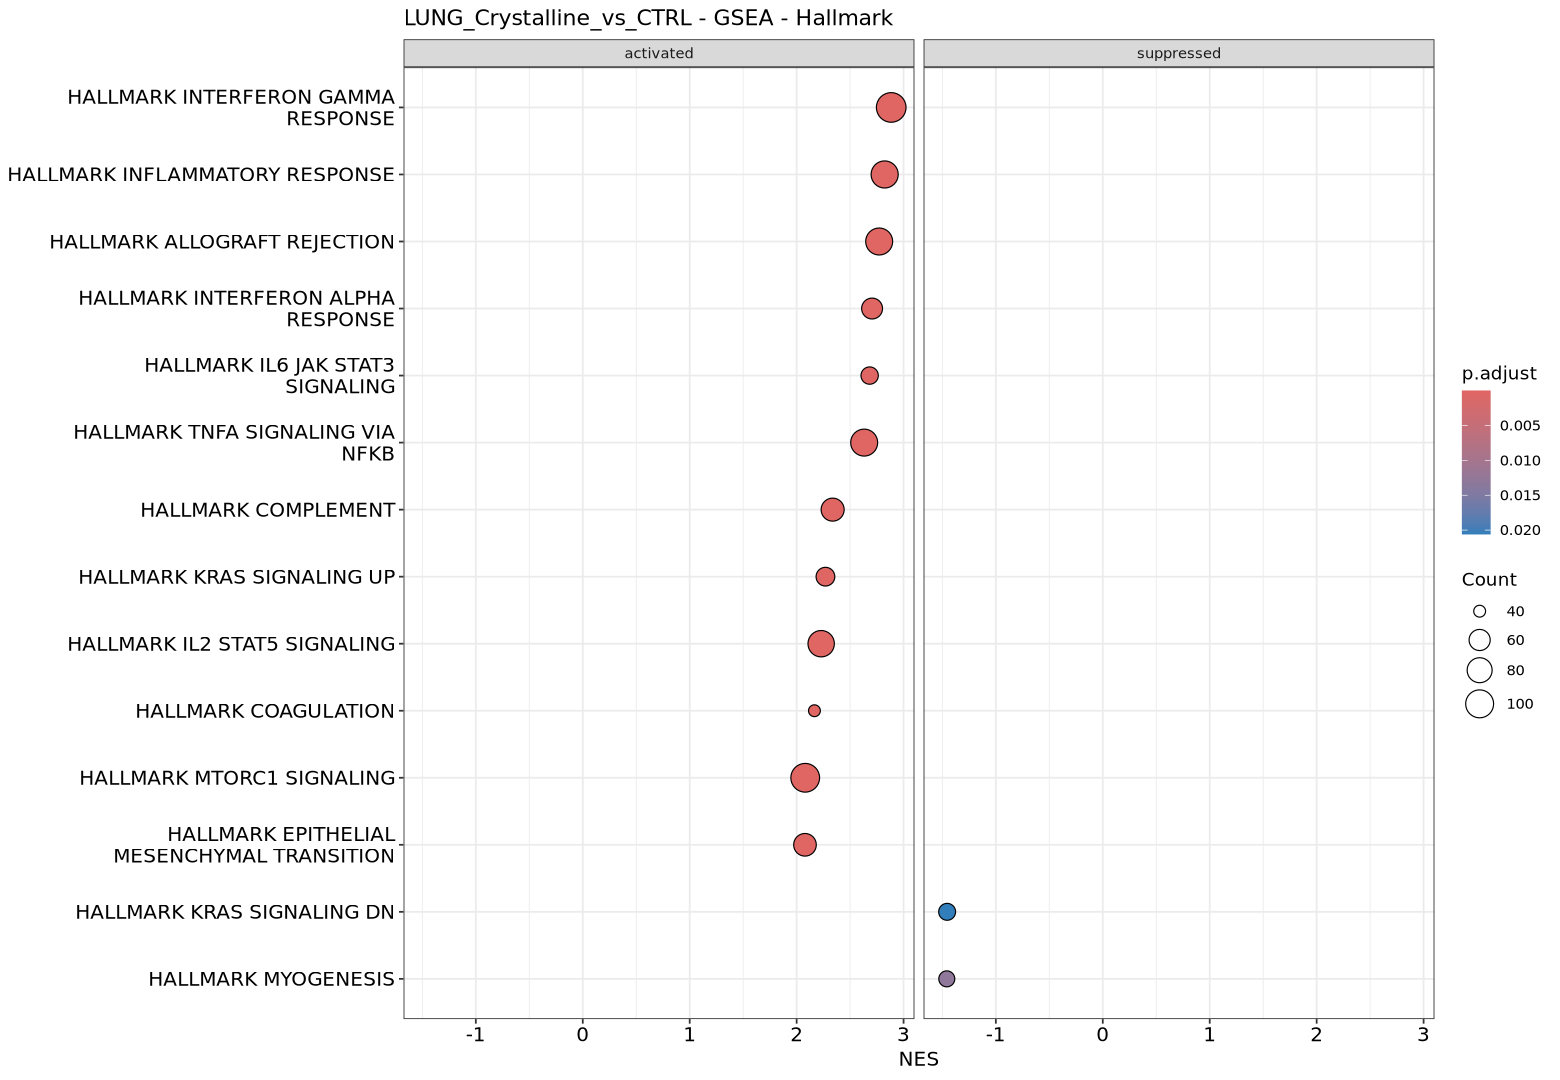

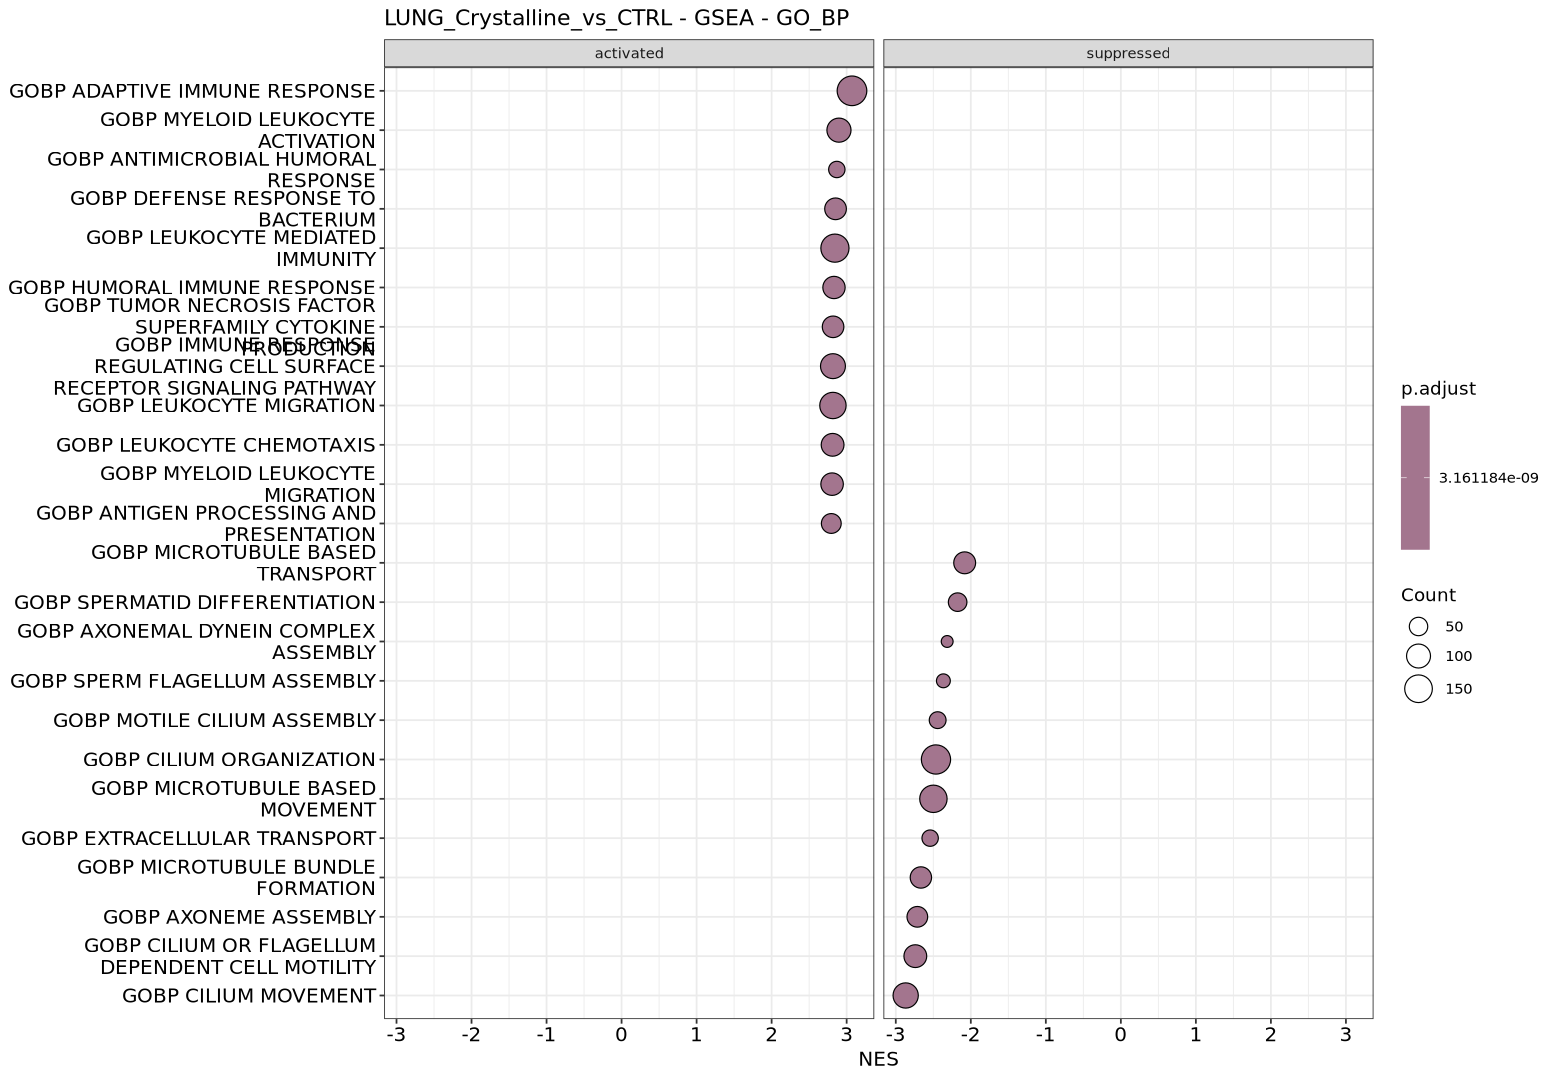

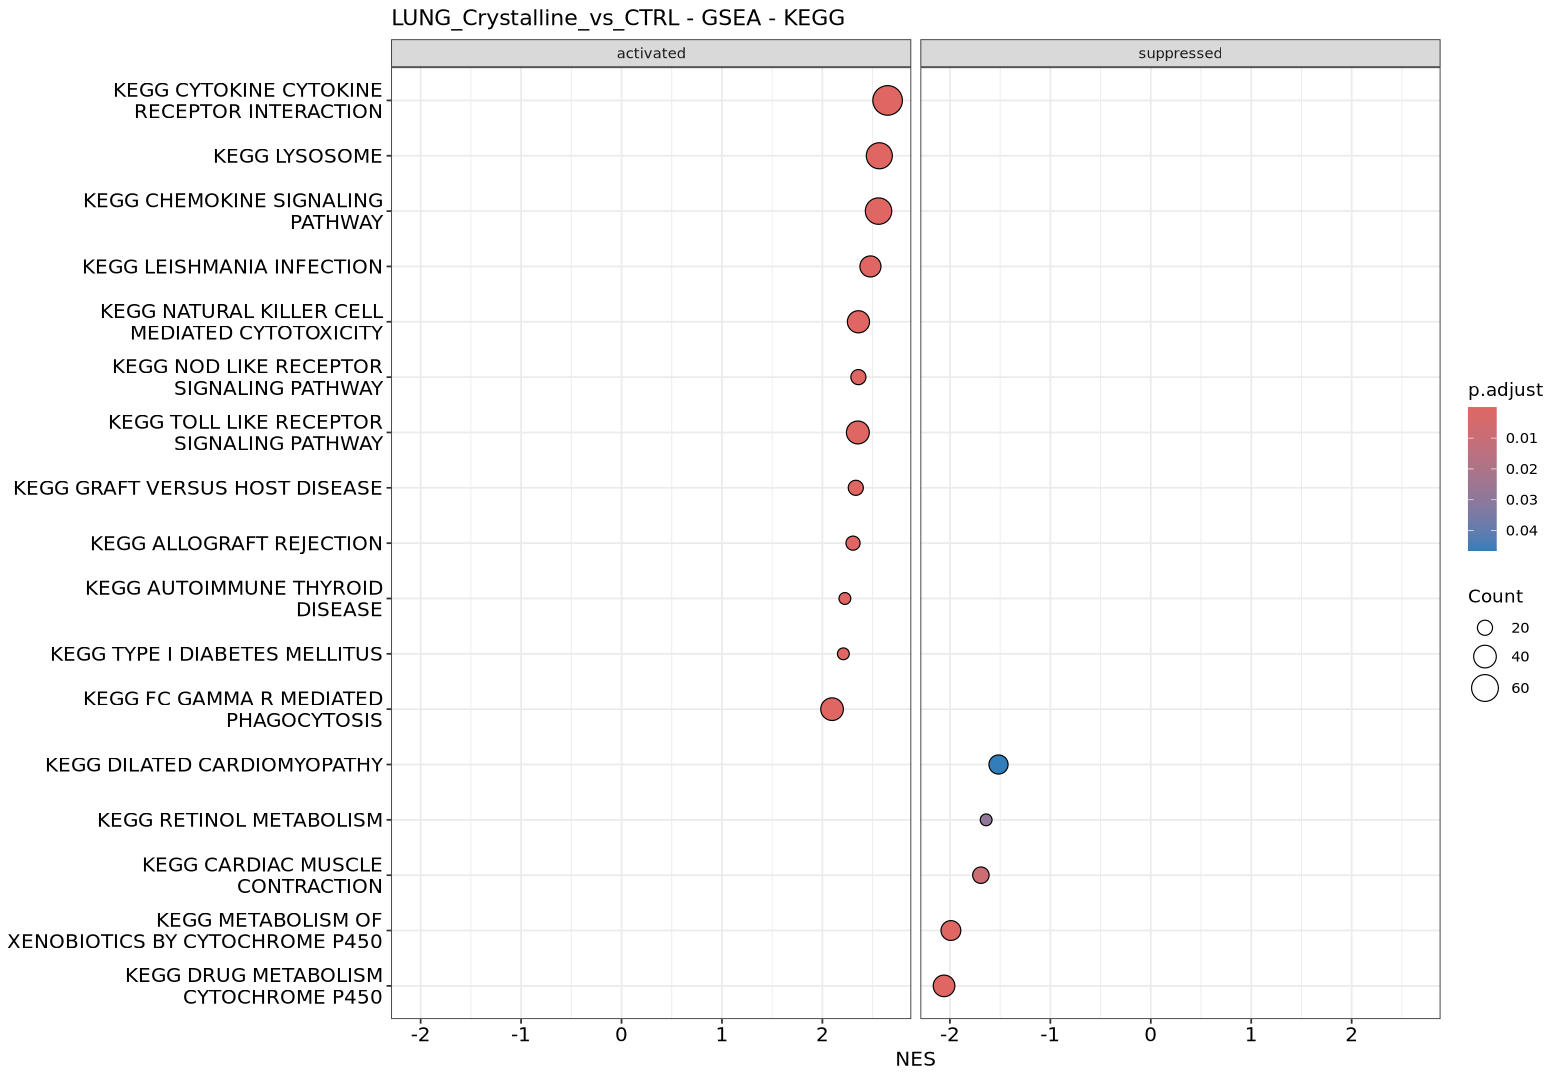

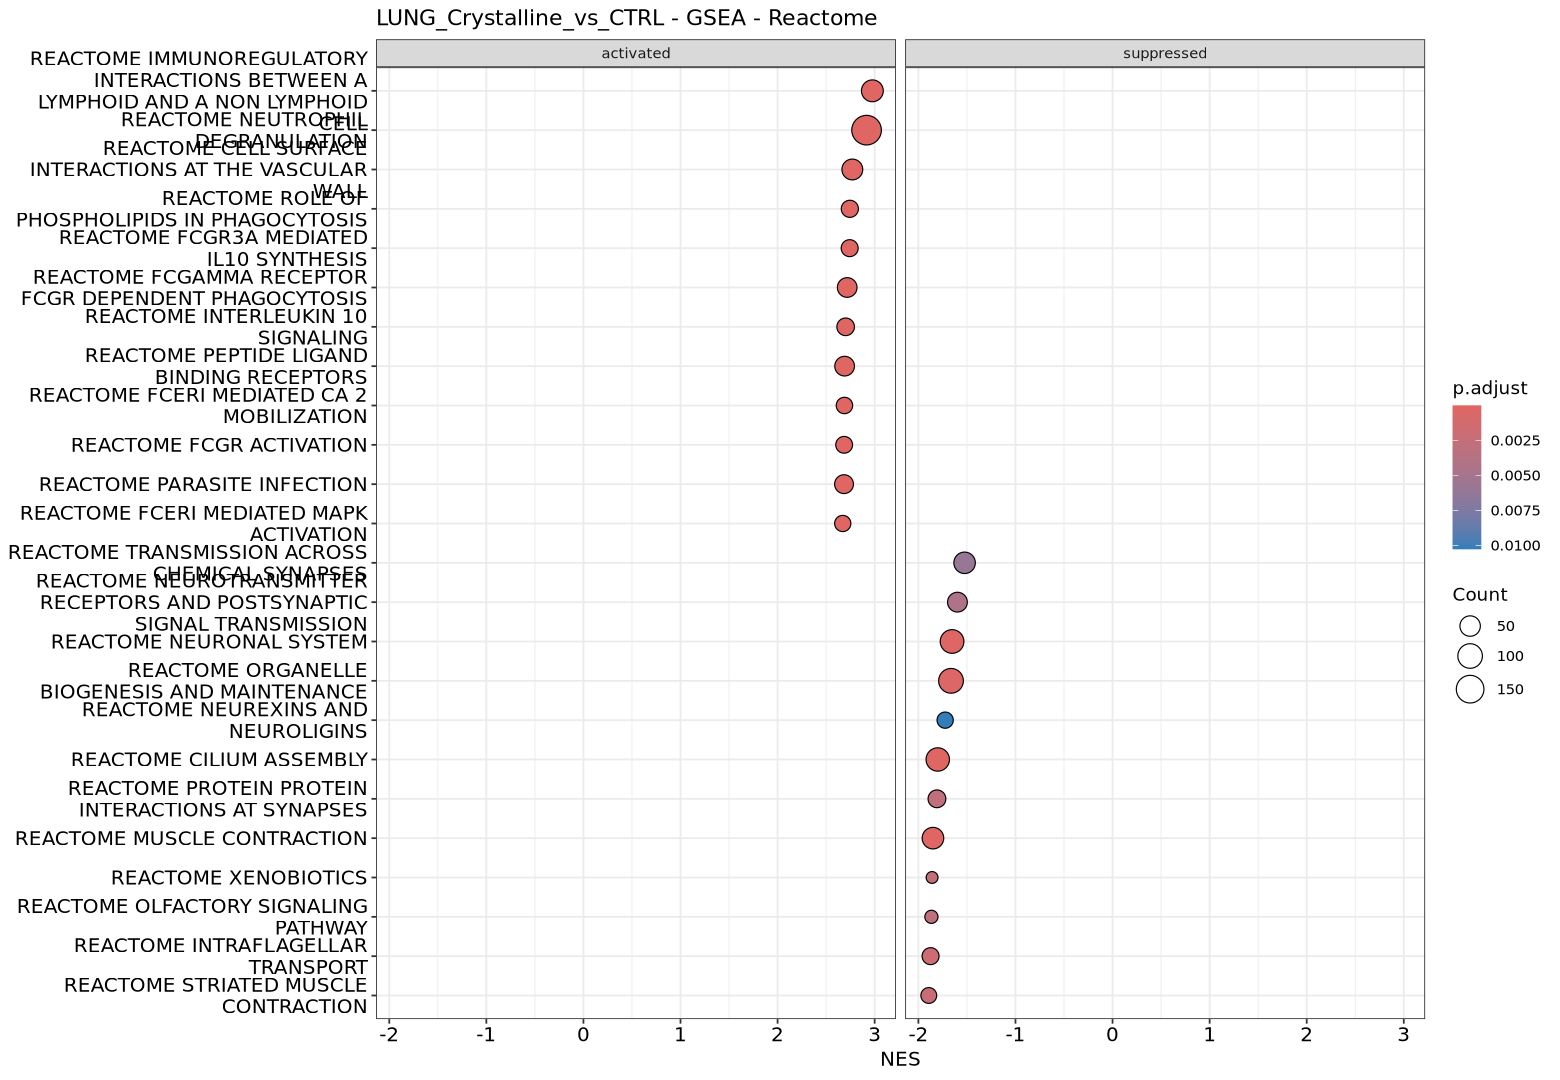

In [15]:
options(repr.plot.width = 13, repr.plot.height = 9)
for (coll in names(gsea_results)) {
  res <- gsea_results[[coll]]
  if (is.null(res) || nrow(as.data.frame(res)) == 0) next

  title <- paste0(CONTRAST_NAME, " - GSEA - ", coll)
  p <- plot_gsea_dotplot(res, show_n = 12, title = title)
  if (is.null(p)) next
  print(p)
  ggsave(file.path(PLOTS_DIR, paste0(CONTRAST_NAME, "_GSEA_", coll, "_dotplot.pdf")),
         p, width = 13, height = 9)
}

### Top GSEA enrichment plots

Show the top 5 most-significant gene sets from GO:BP as classic enrichment plots. These are useful for figures because they show the running enrichment score and the position of pathway genes in your ranked list.

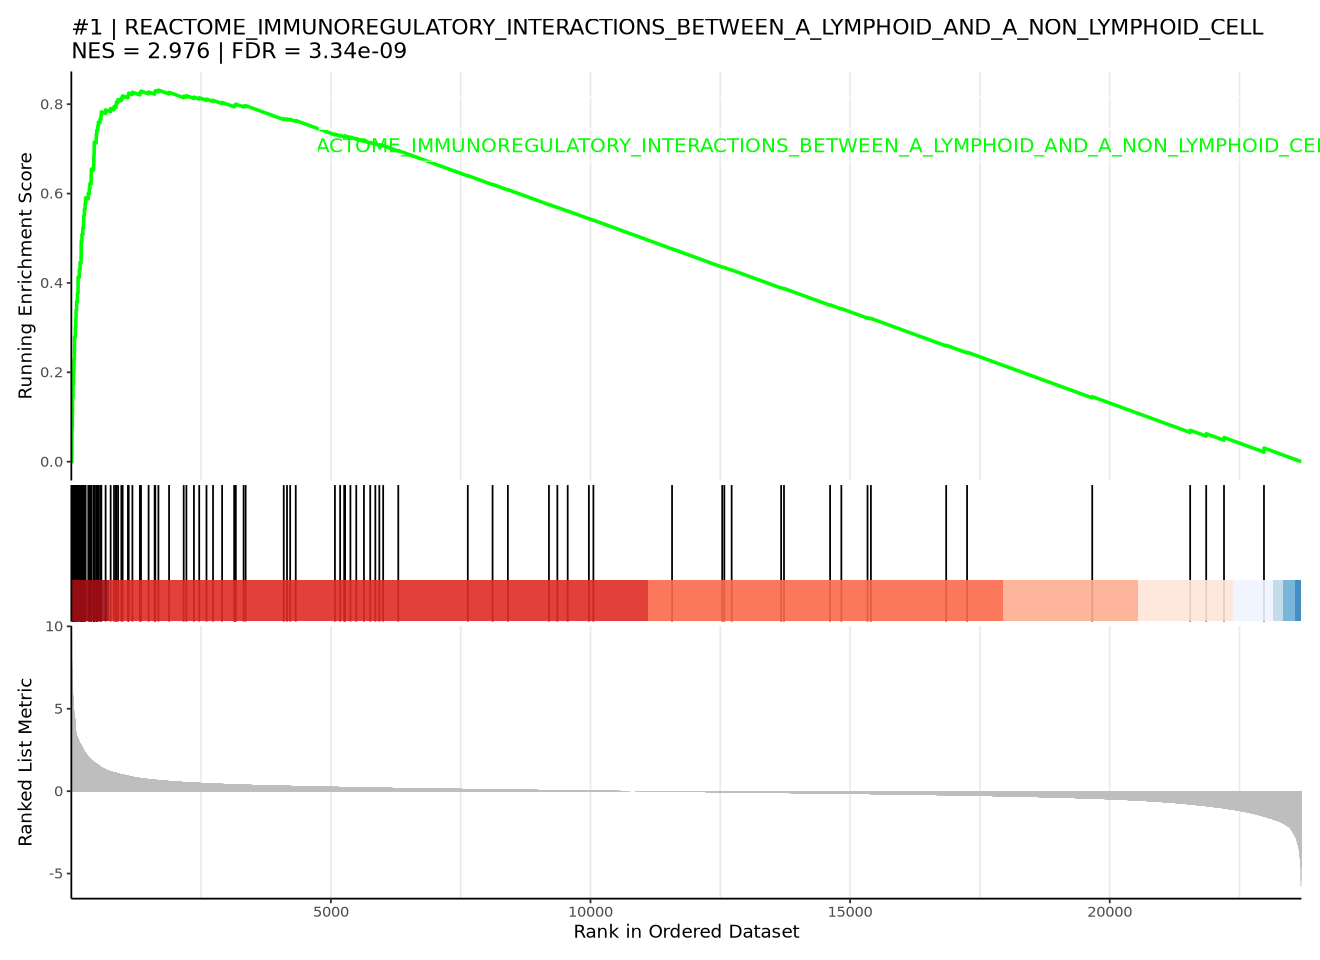

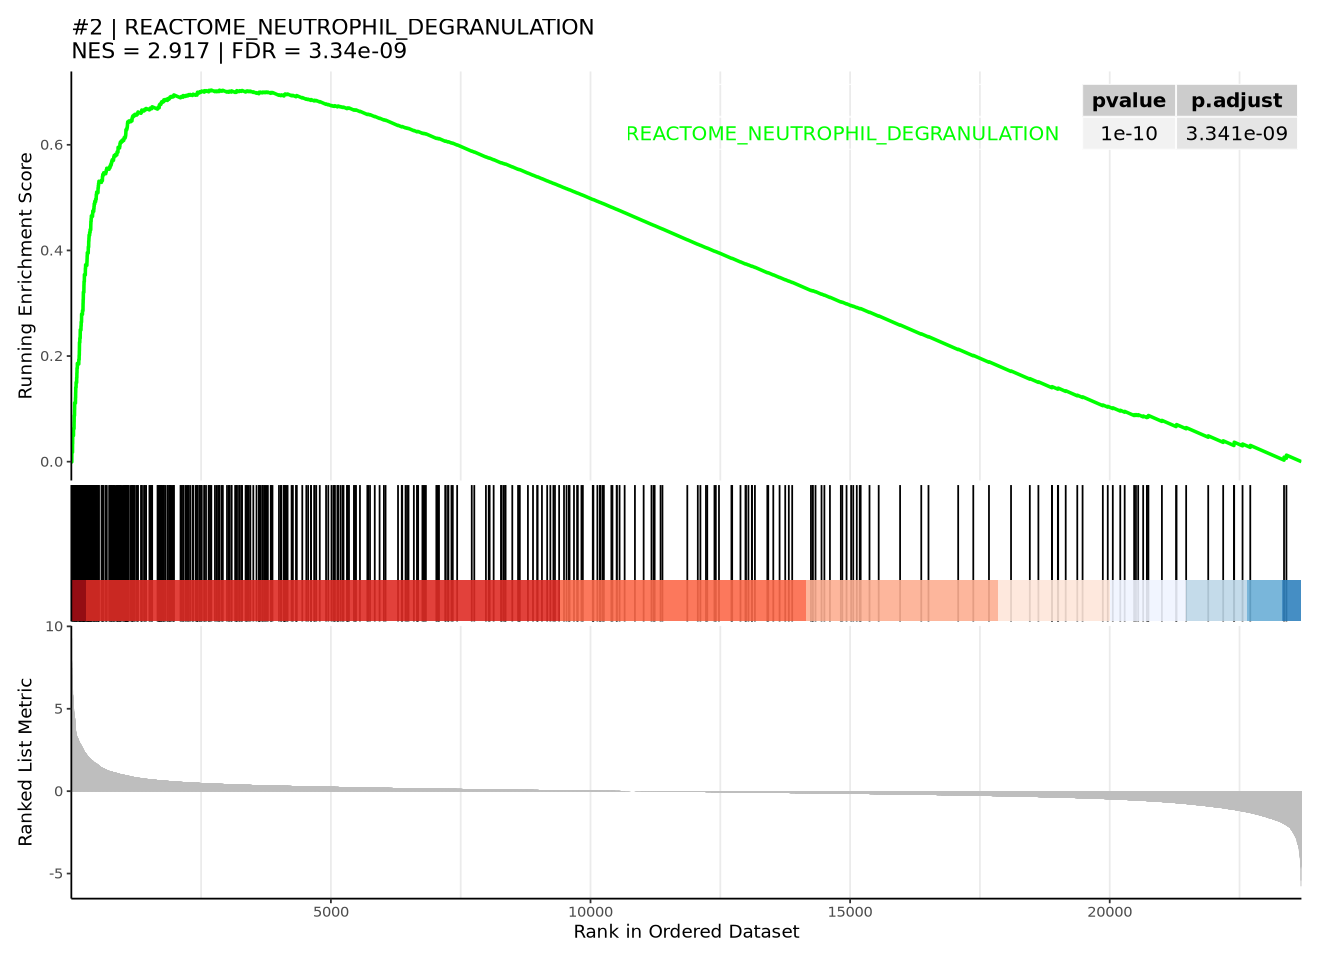

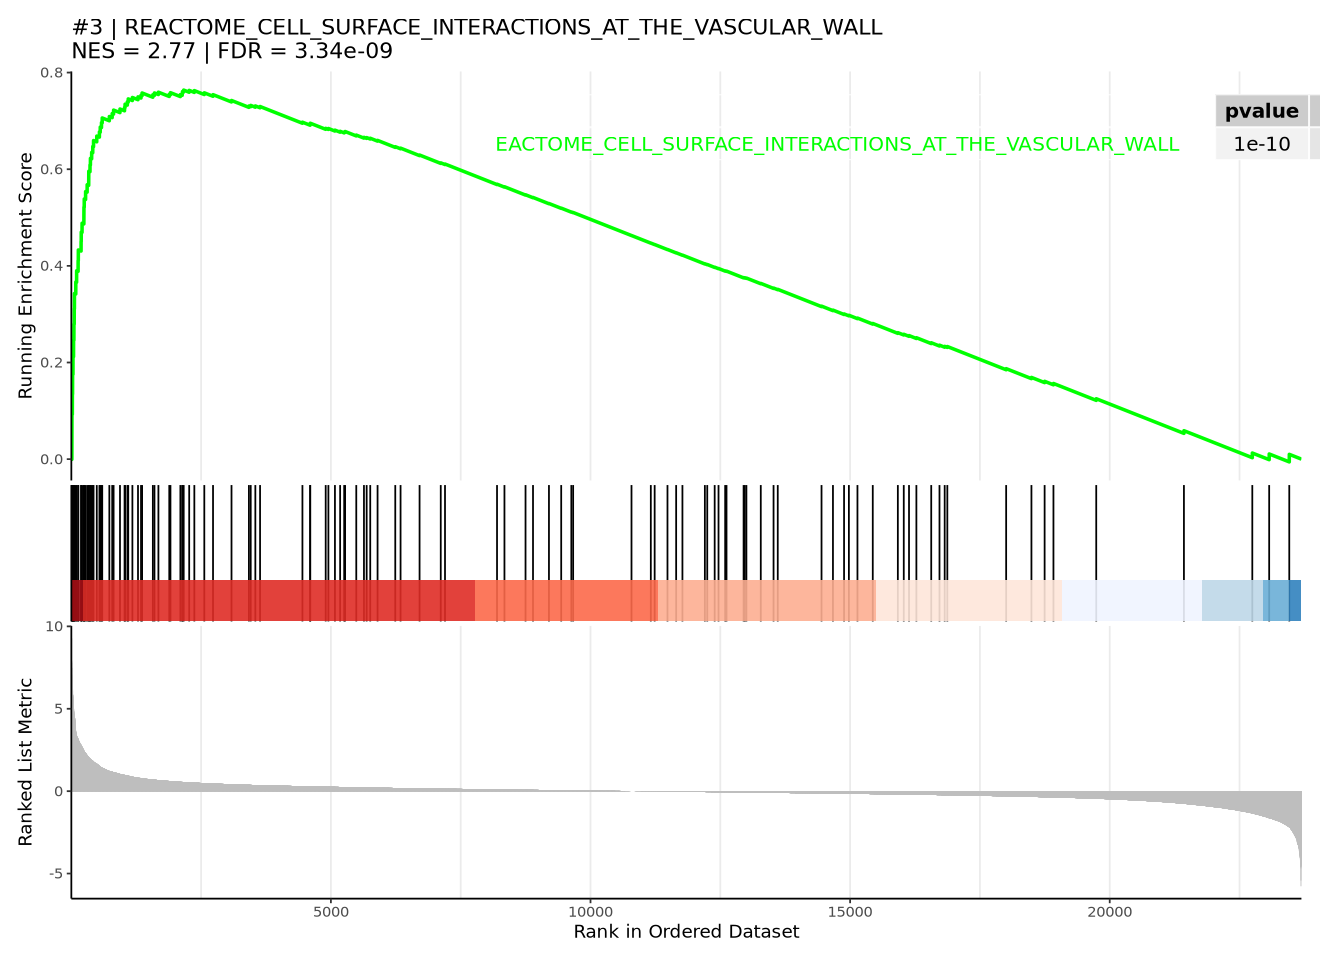

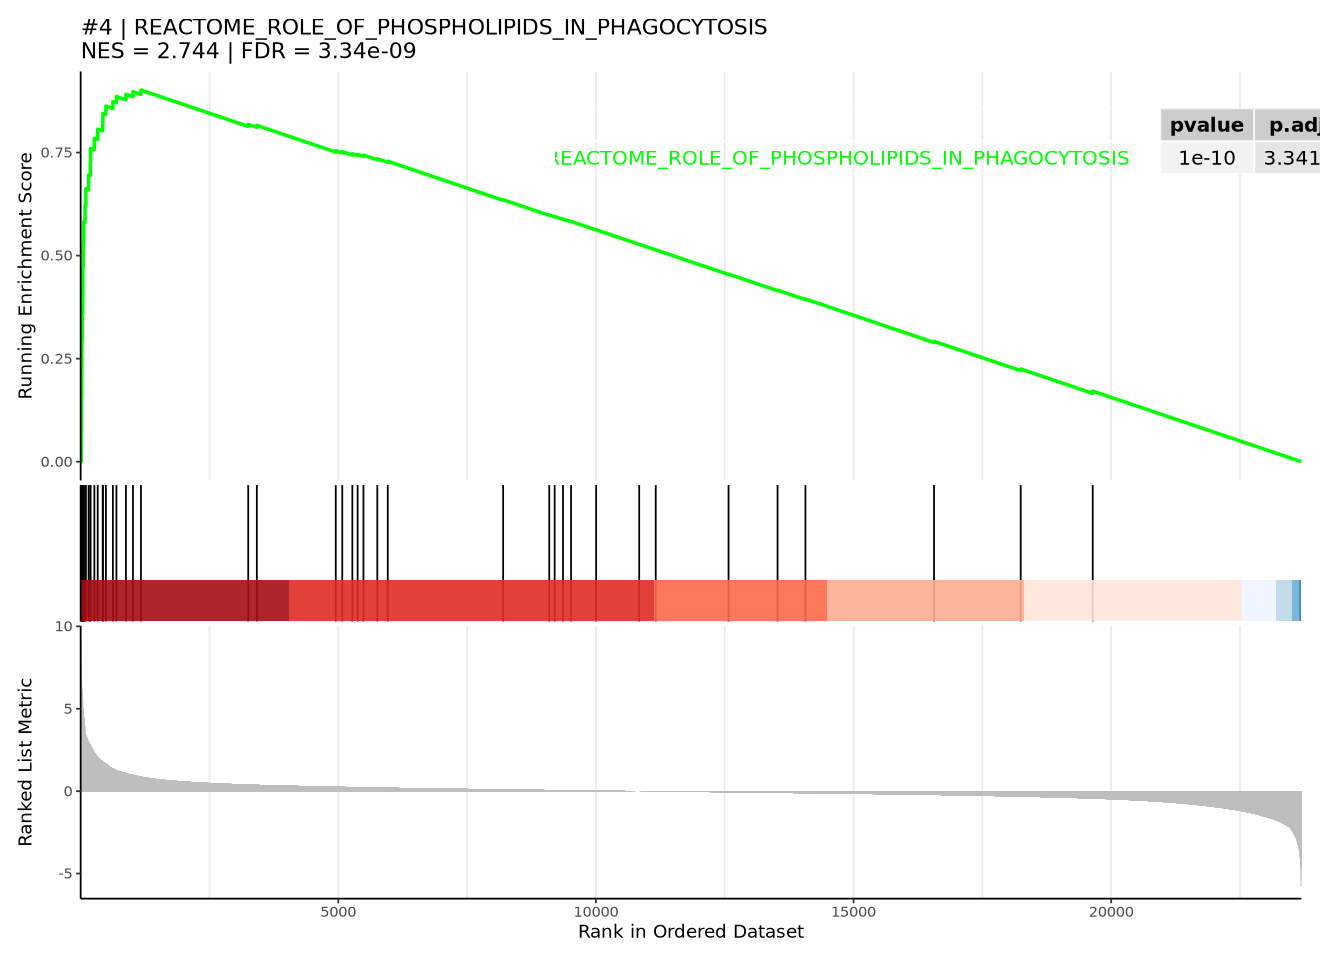

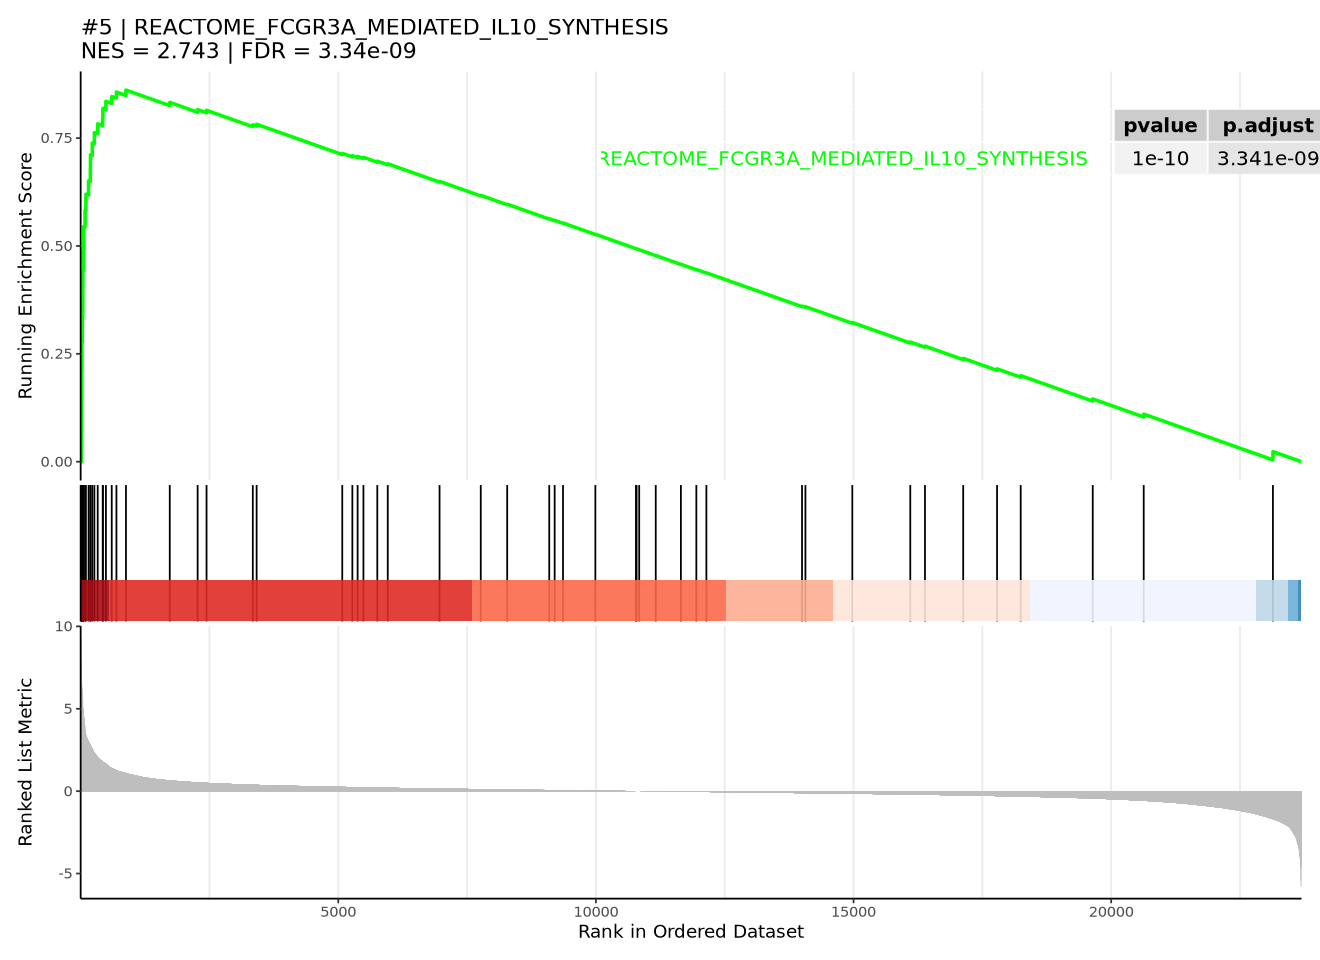

In [16]:
# Pick a collection that's likely informative (GO:BP usually is)
focal_collection <- "Reactome"
options(repr.plot.width = 11, repr.plot.height = 8)
plot_gsea_top_n(gsea_results[[focal_collection]],
                n = 5,
                save_dir = PLOTS_DIR,
                prefix = paste0(CONTRAST_NAME, "_GSEA_", focal_collection))

## 9. Publication-Style bar plot

Saved: enrichment_lung/plots/LUNG_Crystalline_vs_CTRL_gsea_bars_hallmark.pdf 
       enrichment_lung/plots/LUNG_Crystalline_vs_CTRL_gsea_bars_hallmark.png 


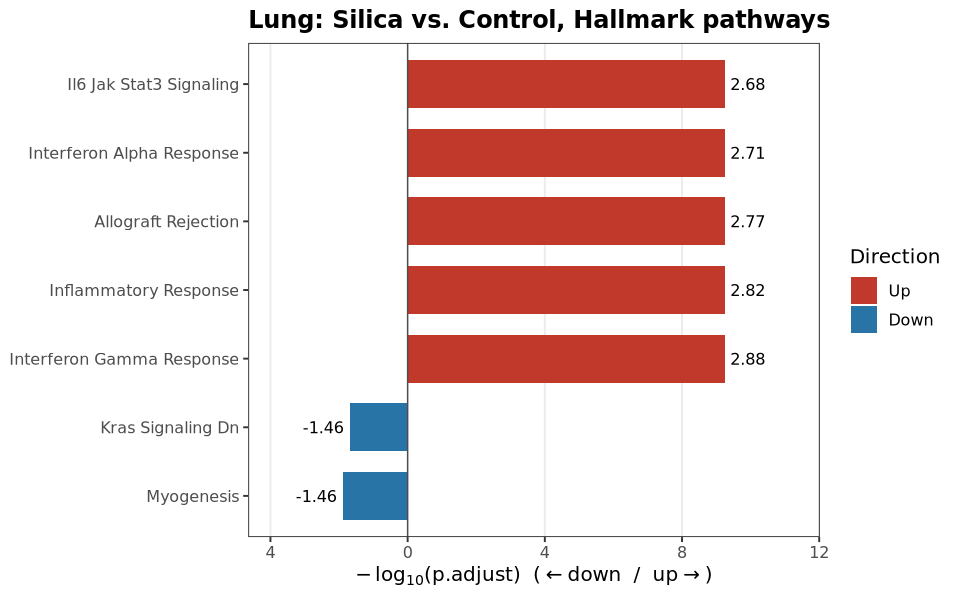

In [17]:
# === Publication-style horizontal bar plot ===
# Hallmark GSEA results, top 5 up + top 5 down by padj.
# Saves both PDF (vector for figures) and PNG (300 dpi for slides).

p_bars <- plot_gsea_horizontal_bars(
  gsea_results[["Hallmark"]],
  n_up = 5, n_down = 5,
  #title = paste0(CONTRAST_NAME, " - Hallmark pathways")
  title = ("Lung: Silica vs. Control, Hallmark pathways")
)

options(repr.plot.width = 8, repr.plot.height = 5)
print(p_bars)

# Save - both formats
bar_path_pdf <- file.path(PLOTS_DIR, paste0(CONTRAST_NAME, "_gsea_bars_hallmark.pdf"))
bar_path_png <- file.path(PLOTS_DIR, paste0(CONTRAST_NAME, "_gsea_bars_hallmark.png"))
ggsave(bar_path_pdf, p_bars, width = 8, height = 5)
ggsave(bar_path_png, p_bars, width = 8, height = 5, dpi = 300)
cat("Saved:", bar_path_pdf, "\n      ", bar_path_png, "\n")

## 10. Session info

In [18]:
sessionInfo()
capture.output(sessionInfo(),
               file = file.path(OUTPUT_DIR, "sessionInfo.txt"))
Sys.time()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Red Hat Enterprise Linux 9.6 (Plow)

Matrix products: default
BLAS/LAPACK: /nfs/roberts/project/pi_epm38/jfd42/ycrc_conda/envs/20260429bulkrnaseq/lib/libopenblasp-r0.3.32.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggrepel_0.9.6          pheatmap_1.0.13        RColorBrewer_1.1-3    
 [4] openxlsx_4.2.8         msigdbr_25.1.1         enrichplot_1.22.0     
 [7] clusterProfiler_4.10.0 lubridate_1.9.4        forcats_1.0.0         
[10] 

[1] "2026-07-31 12:44:25 EDT"